# Проект "Предсказание клика"

**Наша задача**  

Нам предстоит построить модель бинарной классификации, которая предсказывает вероятность клика (CTR) на рекламное объявление. Далее необходимо провести калибровку этой модели, чтобы обеспечить соответствие между предсказанными вероятностями и фактической частотой кликов.

**Калибровка предсказаний модели**

Бизнес-модель Advandex и аукционы напрямую зависят от достоверности предсказанных вероятностей. Некорректные прогнозы ведут к прямым финансовым потерям.  
Если модель постоянно завышает предсказания, то платформа будет переплачивать за показы и выигрывать аукционы по невыгодной цене. Так, при реальной кликабельности в 5% предсказанное значение CTR, равное 20%, сожжёт бюджет рекламодателей и подорвёт их доверие к платформе.
Если модель пессимистично оценивает перспективные объявления, предсказывая шанс клика в 5% вместо реальных 20%, платформа будет проигрывать аукционы, упуская потенциальный доход от кликов.  
Таким образом, наша цель — добиться, чтобы предсказанные вероятности кликов максимально точно соответствовали их реальной частоте. Когда модель предсказывает 20%, это должно означать, что клик произойдёт в среднем в 20 случаях из 100. В результате мы получим не просто точную, но и достоверную модель, предсказаниям которой можно доверять при принятии финансовых решений на аукционе.  

**Выбор метрик**  
Для оценки модели в этом проекте используем три ключевые метрики:
- PR-AUC — основная метрика. Она наиболее адекватно оценивает качество модели на несбалансированных данных. Клики — это более редкое событие, чем пропуск рекламы, но при этом оно критически важно для бизнеса. Поэтому метрика PR-AUC идеально подойдёт. Она игнорирует дисбаланс классов и позволяет оценить, насколько хорошо модель находит именно целевые действия — клики.
- Log Loss позволит оценить точность предсказанных вероятностей. Это важно, чтобы оптимизировать ставки на аукционах, где от достоверности вероятностей напрямую зависит эффективность расходов рекламодателей.
- Оценка Бриера измеряет и точность, и калибровку модели, то есть общее соответствие прогнозов реальным результатам. Для платформы это имеет прямое финансовое значение, так как ошибки в прогнозах приводят либо к переплатам, либо к упущенной выгоде.
При необходимости используйте дополнительные метрики. Они могут помочь в спорных ситуациях:
- Для детального анализа калибровки пригодятся метрики ECE и MCE. Они оценивают, насколько хорошо откалиброваны предсказанные вероятности по разным диапазонам.

**Вспомогательные метрики точности:**
- Precision — точность предсказания кликов.
- Recall — полнота охвата реальных кликов.
- F1-score — балансирует точность и полноту.

# Признаки в датасете

**Идентификаторы и временные метки:**  
`id` — уникальный идентификатор записи о показе баннера;  
`hour` — час, в который был показан баннер, в формате YYMMDDHH.  

**Характеристики рекламной площадки ( Site ):**  
`site_id` — идентификатор веб-сайта, на котором был показан баннер;  
`site_domain` — домен веб-сайта;  
`site_category` — тематическая категория веб-сайта.  

**Характеристики рекламируемого приложения ( App ):**  
`app_id` — идентификатор рекламируемого мобильного приложения;  
`app_domain` — домен рекламируемого приложения;  
`app_category` — категория рекламируемого приложения.  

**Характеристики устройства и соединения пользователя:**  
`device_id` — идентификатор браузера или устройства;  
`device_ip` — IP-адрес устройства;  
`device_model` — модель устройства;  
`device_type` — тип устройства пользователя: например, смартфон, планшет, ПК;  
`device_conn_type` — тип сетевого соединения устройства: например, Wi-Fi, 3G, 4G.  

**Характеристики рекламного баннера и аукциона:**  
`C1` — анонимизированный признак, характеризующий контекст показа;  
`banner_pos` — позиция баннера на веб-странице;  
`C14 — C21` — группа анонимизированных признаков, описывающих параметры баннера, пользователя или аукциона. 

**Машинно-сгенерированные признаки (ML Features):**  
`ml_feature_1`, `ml_feature_3` — `ml_feature_6`, `ml_feature_8` — `ml_feature_10` — числовые признаки, полученные в результате предварительной обработки и генерации новых признаков;  
`ml_feature_2`, `ml_feature_7` — категориальные признаки, полученные в результате предварительной обработки и генерации новых признаков.  

**Целевая переменная:**  
`click` — бинарный признак, указывающий, был ли совершён клик по баннеру. 1 — клик был, 0 — клика не было.  

# Структура проекта

##  Подготовка среды и загрузка данных

In [1]:
!pip install phik -q
!pip install category_encoders -q

In [2]:
import numpy as np
import joblib
import pandas as pd
import matplotlib.pyplot as plt
from phik import phik_matrix
from datetime import datetime
from tqdm import tqdm


from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import TargetEncoder, OneHotEncoder, StandardScaler, FunctionTransformer
import seaborn as sns
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.dummy import DummyClassifier
from sklearn.feature_selection import mutual_info_classif, VarianceThreshold, SequentialFeatureSelector, RFE
from sklearn.model_selection import KFold, cross_validate, StratifiedKFold, train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import log_loss, average_precision_score, brier_score_loss, make_scorer, precision_score, recall_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import calibration_curve, CalibrationDisplay, CalibratedClassifierCV
from sklearn.svm import SVC, LinearSVC

RANDOM_SEED = 42

In [3]:
#Загружаем датасет в переменную 
try:
    df = pd.read_csv('/datasets/ds_s16_ad_click_dataset.csv')
except:
    df = pd.read_csv('https://code.s3.yandex.net/datasets/ds_s16_ad_click_dataset.csv')
df.head()

,id,click,hour,C1,banner_pos,site_id,site_domain,site_category,app_id,app_domain,...,ml_feature_1,ml_feature_2,ml_feature_3,ml_feature_4,ml_feature_5,ml_feature_6,ml_feature_7,ml_feature_8,ml_feature_9,ml_feature_10
0,1.005263e+19,1,14102100,1005,1,d9750ee7,98572c79,f028772b,ecad2386,7801e8d9,...,-0.996823,A,0.666588,0,0.817292,0.993275,Z,-0.619959,0.433666,0.274038
1,1.010597e+19,0,14102100,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,...,-0.391309,C,5.146789,1,-0.883865,-0.825722,X,0.576526,-0.318558,-0.132851
2,1.012048e+19,0,14102100,1005,0,d9750ee7,98572c79,f028772b,ecad2386,7801e8d9,...,-2.112732,D,7.169348,0,-0.859440,-0.338365,Y,-0.440047,-0.345412,0.340487
3,1.021995e+18,0,14102100,1005,0,85f751fd,c4e18dd6,50e219e0,39cfef32,d9b5648e,...,0.332707,A,-0.290708,1,0.062795,0.062934,Y,0.551982,0.733382,-0.198542
4,1.023455e+19,0,14102100,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,...,1.166623,A,6.319134,1,-0.675276,0.797144,X,0.640827,0.297955,-0.136909


In [4]:
#Делаем копию датафрейма
temp = df.copy()
#выводим размерность
df.shape

(50000, 34)

Датафрейм имеет размеры в 50000 строк и 34 столбца. 

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 34 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                50000 non-null  float64
 1   click             50000 non-null  int64  
 2   hour              50000 non-null  int64  
 3   C1                50000 non-null  int64  
 4   banner_pos        50000 non-null  int64  
 5   site_id           50000 non-null  object 
 6   site_domain       50000 non-null  object 
 7   site_category     50000 non-null  object 
 8   app_id            50000 non-null  object 
 9   app_domain        50000 non-null  object 
 10  app_category      50000 non-null  object 
 11  device_id         50000 non-null  object 
 12  device_ip         50000 non-null  object 
 13  device_model      50000 non-null  object 
 14  device_type       50000 non-null  int64  
 15  device_conn_type  50000 non-null  int64  
 16  C14               50000 non-null  int64 

Данные представлены корректно

## Исследовательский анализ данных (EDA)

### Базовая информацию о датасете


**Общее описание данных**  
Представленный датасет содержит информацию о показах и кликах рекламных объявлений. Разберём его характеристики подробно.

Основные параметры датасета
- Количество записей: 50 000.

- Количество столбцов: 34.

- Пропусков в данных нет: все столбцы содержат 50 000 непустых значений (non-null).

Типы данных:

- float64 — 8 столбцов;

- int64 — 15 столбцов;

- object — 11 столбцов.

### Анализ целевой переменной


In [6]:
# Подсчёт количества записей для каждого класса
click_counts = df['click'].value_counts()
click_percentages = df['click'].value_counts(normalize=True) * 100


# Выводим результаты
print("РАСПРЕДЕЛЕНИЕ ЦЕЛЕВОЙ ПЕРЕМЕННОЙ 'click':")
print("-" * 40)
print(f"Количество записей:")
print(f"  Не кликнули (click = 0): {click_counts[0]:,}")
print(f"  Кликнули (click = 1):   {click_counts[1]:,}")
print()
print(f"Доли:")
print(f"  Не кликнули (click = 0): {click_percentages[0]:.2f}%")
print(f"  Кликнули (click = 1):   {click_percentages[1]:.2f}%")

# Дополнительно: выводим общее количество записей для проверки
print(f"\nОбщее количество записей: {len(df):,}")

РАСПРЕДЕЛЕНИЕ ЦЕЛЕВОЙ ПЕРЕМЕННОЙ 'click':
----------------------------------------
Количество записей:
  Не кликнули (click = 0): 41,397
  Кликнули (click = 1):   8,603

Доли:
  Не кликнули (click = 0): 82.79%
  Кликнули (click = 1):   17.21%

Общее количество записей: 50,000


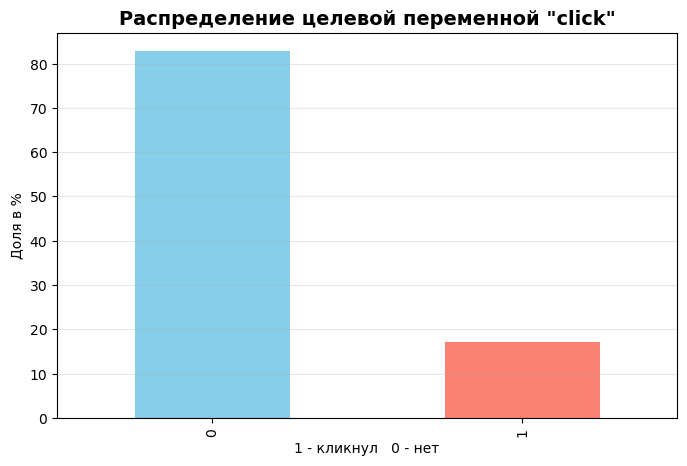

In [7]:
click_percentages.plot(kind='bar', color=['skyblue', 'salmon'],
                       figsize=(8, 5)
                       )
plt.title('Распределение целевой переменной "click"', fontsize=14, fontweight='bold')
plt.xlabel('1 - кликнул   0 - нет')
plt.ylabel('Доля в %')
plt.grid(axis='y', alpha=0.3)
plt.show()


Из‑за умеренного дисбаланса не рекомендуется полагаться только на Accuracy (точность). Модель, которая всегда предсказывает «не клик», даст 82,79 % точности — это завышенная оценка её реальной полезности.

**Рекомендуемые метрики:**

- F1‑score — гармоническое среднее между Precision и Recall, хорошо подходит для несбалансированных данных.

- Precision (точность) — доля верных предсказаний класса «клик» среди всех предсказанных кликов.

- Recall (полнота) — доля верно предсказанных кликов среди всех реальных кликов.

- PR‑AUC (Precision‑Recall AUC) — особенно полезна при дисбалансе, фокусируется на качестве предсказания положительного класса.

- Log Loss — учитывает уверенность модели в предсказаниях.

### Анализ признаков

Перед удалением признаков проверим наличие дубликатов

In [8]:
dub_full = df.duplicated().sum()
print('Обнаружено явных дубликатов:', dub_full)
dub_id = df['id'].duplicated().sum()
print('Обнаружено дубликатов по столбцу ID:', dub_id)

Обнаружено явных дубликатов: 0
Обнаружено дубликатов по столбцу ID: 0


**Явно бесполезные (рекомендуется удалить):**

- id — уникальный идентификатор. Не несёт предсказательной силы, только усложняет обучение.

- device_ip — IP‑адреса. Слишком высокая кардинальность (уникальных значений почти столько же, сколько записей), малоинформативны для обобщения. Могут привести к переобучению.

- device_id — идентификаторы устройств. Аналогично IP: высокая кардинальность, риск переобучения без реальной пользы.

**Признаки с ограниченной полезностью (требует анализа):**

- site_id, app_id — высокая кардинальность. Возможно, стоит оставить только site_category и app_category.

- site_domain, app_domain — домены. Высокая кардинальность, но могут содержать полезную информацию (например, популярные платформы). Можно попробовать извлечь признаки (доменная зона, длина домена и т. д.) или удалить.

- device_model — модели устройств. Высокая кардинальность; возможно, достаточно device_type.

**Полезные признаки:**

- Временные: hour — час показа может влиять на CTR.

- Позиционные: banner_pos — позиция баннера важна для CTR.

- Контекстные площадки: site_category, app_category — категории сайтов/приложений несут обобщённую информацию.

**Характеристики устройства:**

- device_type, device_conn_type — влияют на поведение пользователя.

- C‑признаки (C1, C14–C21) — закодированные параметры таргетинга/сегментов. Вероятно, полезны.

- ML‑признаки (ml_feature_*) — сгенерированы моделью, скорее всего, информативны. Особенно числовые (ml_feature_1 и др.).

**Изучим корректность типа данных в признаках**  
Данные info()

**float64**(8) - `ml_feature_1, ml_feature_3, ml_feature_5, ml_feature_6, ml_feature_8, ml_feature_9, ml_feature_10, id`

**int64**(15) - `click, hour, banner_pos, device_type, device_conn_type, C1, C14–C21`

**object**(11) - `site_id, site_domain, site_category, app_id, app_domain, app_category, device_id, device_ip, device_model, ml_feature_2, ml_feature_7`

In [9]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

In [10]:
df.head()

,id,click,hour,C1,banner_pos,site_id,site_domain,site_category,app_id,app_domain,app_category,device_id,device_ip,device_model,device_type,device_conn_type,C14,C15,C16,C17,C18,C19,C20,C21,ml_feature_1,ml_feature_2,ml_feature_3,ml_feature_4,ml_feature_5,ml_feature_6,ml_feature_7,ml_feature_8,ml_feature_9,ml_feature_10
0,1.005263e+19,1,14102100,1005,1,d9750ee7,98572c79,f028772b,ecad2386,7801e8d9,07d7df22,a99f214a,488a9a3e,31025cda,1,0,17614,320,50,1993,2,1063,-1,33,-0.996823,A,0.666588,0,0.817292,0.993275,Z,-0.619959,0.433666,0.274038
1,1.010597e+19,0,14102100,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,07d7df22,a99f214a,75bb1b58,2ee63ff8,1,0,15701,320,50,1722,0,35,-1,79,-0.391309,C,5.146789,1,-0.883865,-0.825722,X,0.576526,-0.318558,-0.132851
2,1.012048e+19,0,14102100,1005,0,d9750ee7,98572c79,f028772b,ecad2386,7801e8d9,07d7df22,a99f214a,285263b0,d780319b,1,0,17914,320,50,2043,2,39,100084,32,-2.112732,D,7.169348,0,-0.859440,-0.338365,Y,-0.440047,-0.345412,0.340487
3,1.021995e+18,0,14102100,1005,0,85f751fd,c4e18dd6,50e219e0,39cfef32,d9b5648e,0f2161f8,a99f214a,18190986,f4fffcd0,1,0,21611,320,50,2480,3,297,100111,61,0.332707,A,-0.290708,1,0.062795,0.062934,Y,0.551982,0.733382,-0.198542
4,1.023455e+19,0,14102100,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,07d7df22,a99f214a,b66e5482,a0f5f879,1,0,15702,320,50,1722,0,35,100084,79,1.166623,A,6.319134,1,-0.675276,0.797144,X,0.640827,0.297955,-0.136909


**Удалим идентификационные признаки**

In [11]:
#Удалячем поля 
column_drop = ['id','device_ip','device_id','site_id','app_id', 'device_model', 'site_domain']
df = df.drop(columns = column_drop)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 27 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   click             50000 non-null  int64  
 1   hour              50000 non-null  int64  
 2   C1                50000 non-null  int64  
 3   banner_pos        50000 non-null  int64  
 4   site_category     50000 non-null  object 
 5   app_domain        50000 non-null  object 
 6   app_category      50000 non-null  object 
 7   device_type       50000 non-null  int64  
 8   device_conn_type  50000 non-null  int64  
 9   C14               50000 non-null  int64  
 10  C15               50000 non-null  int64  
 11  C16               50000 non-null  int64  
 12  C17               50000 non-null  int64  
 13  C18               50000 non-null  int64  
 14  C19               50000 non-null  int64  
 15  C20               50000 non-null  int64  
 16  C21               50000 non-null  int64 

**После удаления явно бесполезных признаков, остались следующие:**  

**float64**(8) - `ml_feature_1, ml_feature_3, ml_feature_5, ml_feature_6, ml_feature_8, ml_feature_9, ml_feature_10`

**int64**(15) - `click, hour, banner_pos, device_type, device_conn_type, C1, ml_feature_4, C14–C21`

**object**(11) -  `site_category,  app_domain, app_category, ml_feature_2, ml_feature_7`

Среди тех, что содержат сугубо числовые значения определим, какие из них относятся к категориальным. 

`hour` - время, не числовое, но и к категориальным отнести нельзя.  
`banner_pos` - позиция банера, категориальное значение  
`device_type` и `device_conn_type` - данные о типе устройства, также отнесём к категориальным.  
`C1` - контекст показа, явно категориальный признак  
`C14–C21` - требуют изучения  

In [13]:
column_C = ['C14','C15','C16','C17','C18','C19','C20','C21']
for i in column_C:
    print(f'Количество уникальных значений в поле {i}', df[i].nunique())
    print(df[i].value_counts())
    print('=' *50)

Количество уникальных значений в поле C14 1497
C14
4687     1200
21611    1083
21191     977
21189     936
19772     911
         ... 
21971       1
15839       1
21954       1
21783       1
18488       1
Name: count, Length: 1497, dtype: int64
Количество уникальных значений в поле C15 8
C15
320     46787
300      2758
216       367
728        78
1024        5
768         3
480         1
120         1
Name: count, dtype: int64
Количество уникальных значений в поле C16 9
C16
50      47287
250      2135
36        367
480       123
90         78
768         5
1024        3
320         1
20          1
Name: count, dtype: int64
Количество уникальных значений в поле C17 387
C17
1722    5637
2424    1913
2227    1822
1800    1481
423     1200
        ... 
2541       1
2689       1
1426       1
2206       1
2527       1
Name: count, Length: 387, dtype: int64
Количество уникальных значений в поле C18 4
C18
0    21074
3    16855
2     8769
1     3302
Name: count, dtype: int64
Количество уникальн

Все поля C15-C21 отнесём к категориальным, C14 имеет достаточно большое количество уникальных, значений, возможно это размерные параметры банера. Отнесем его к числовым

In [14]:
#Список с категориальными полями
cat = ['site_category',  'app_domain',
       'app_category', 'ml_feature_2',
       'ml_feature_7', 'C1', 'banner_pos', 'device_type',
       'device_conn_type', 'C15', 'C16', 'C17',
       'C18', 'C19', 'C20', 'C21']

#Список с числовым полями
num = ['ml_feature_1', 'ml_feature_3', 'ml_feature_4', 
       'ml_feature_5', 'ml_feature_6', 'ml_feature_8', 
       'ml_feature_9', 'ml_feature_10']

### Анализ пропущенных значений

In [15]:
#Находим долю пропусков в полях
df.isna().mean()

click               0.0
hour                0.0
C1                  0.0
banner_pos          0.0
site_category       0.0
app_domain          0.0
app_category        0.0
device_type         0.0
device_conn_type    0.0
C14                 0.0
C15                 0.0
C16                 0.0
C17                 0.0
C18                 0.0
C19                 0.0
C20                 0.0
C21                 0.0
ml_feature_1        0.0
ml_feature_2        0.0
ml_feature_3        0.0
ml_feature_4        0.0
ml_feature_5        0.0
ml_feature_6        0.0
ml_feature_7        0.0
ml_feature_8        0.0
ml_feature_9        0.0
ml_feature_10       0.0
dtype: float64

Анализ показал отсутствие пропущенных значений в датасете.

### Анализ категориальных признаков


In [16]:
for i in cat:
    print(f'Количество уникальных значений в поле {i} =', df[i].nunique())
    print('='*70)

Количество уникальных значений в поле site_category = 18
Количество уникальных значений в поле app_domain = 67
Количество уникальных значений в поле app_category = 22
Количество уникальных значений в поле ml_feature_2 = 5
Количество уникальных значений в поле ml_feature_7 = 3
Количество уникальных значений в поле C1 = 7
Количество уникальных значений в поле banner_pos = 7
Количество уникальных значений в поле device_type = 4
Количество уникальных значений в поле device_conn_type = 4
Количество уникальных значений в поле C15 = 8
Количество уникальных значений в поле C16 = 9
Количество уникальных значений в поле C17 = 387
Количество уникальных значений в поле C18 = 4
Количество уникальных значений в поле C19 = 64
Количество уникальных значений в поле C20 = 149
Количество уникальных значений в поле C21 = 59


**Кодировать с помощью OneHotEncoder**  
*Признаки с низкой кардинальностью (≤ 10):*

- ml_feature_2 (5) — мало категорий, можно закодировать полностью;

- ml_feature_7 (3) — минимальное число категорий;

- C1 (7) — закодированный сегмент, мало вариантов;

- banner_pos (7) — позиции баннера, мало позиций;

- device_type (4) — типы устройств, чётко определённые категории;

- device_conn_type (4) — типы подключения, мало вариантов;

- C15 (8) — закодированный признак с малым числом значений;

- C16 (9) — аналогично;

- C18 (4) — очень низкая кардинальность;


**Кодировать с помощью TargetEncoder**  
*Признаки со средней/высокой кардинальностью (> 10):*

- site_category (18 уникальных значений) — категории сайтов, мало классов, все важны;

- app_category (22) — категории приложений, аналогичная логика;

- app_domain (67) — домены приложений, умеренная, но значимая кардинальность;

- C17 (387) — закодированный признак, много категорий;

- C19 (64) — умеренная кардинальность, но лучше сжать до одного признака;

- C20 (149) — средняя кардинальность, много категорий с малой частотой;

- C21 (59) - умеренная кардинальность, лучше сжать до одного признака

### Анализ выбросов и распределений


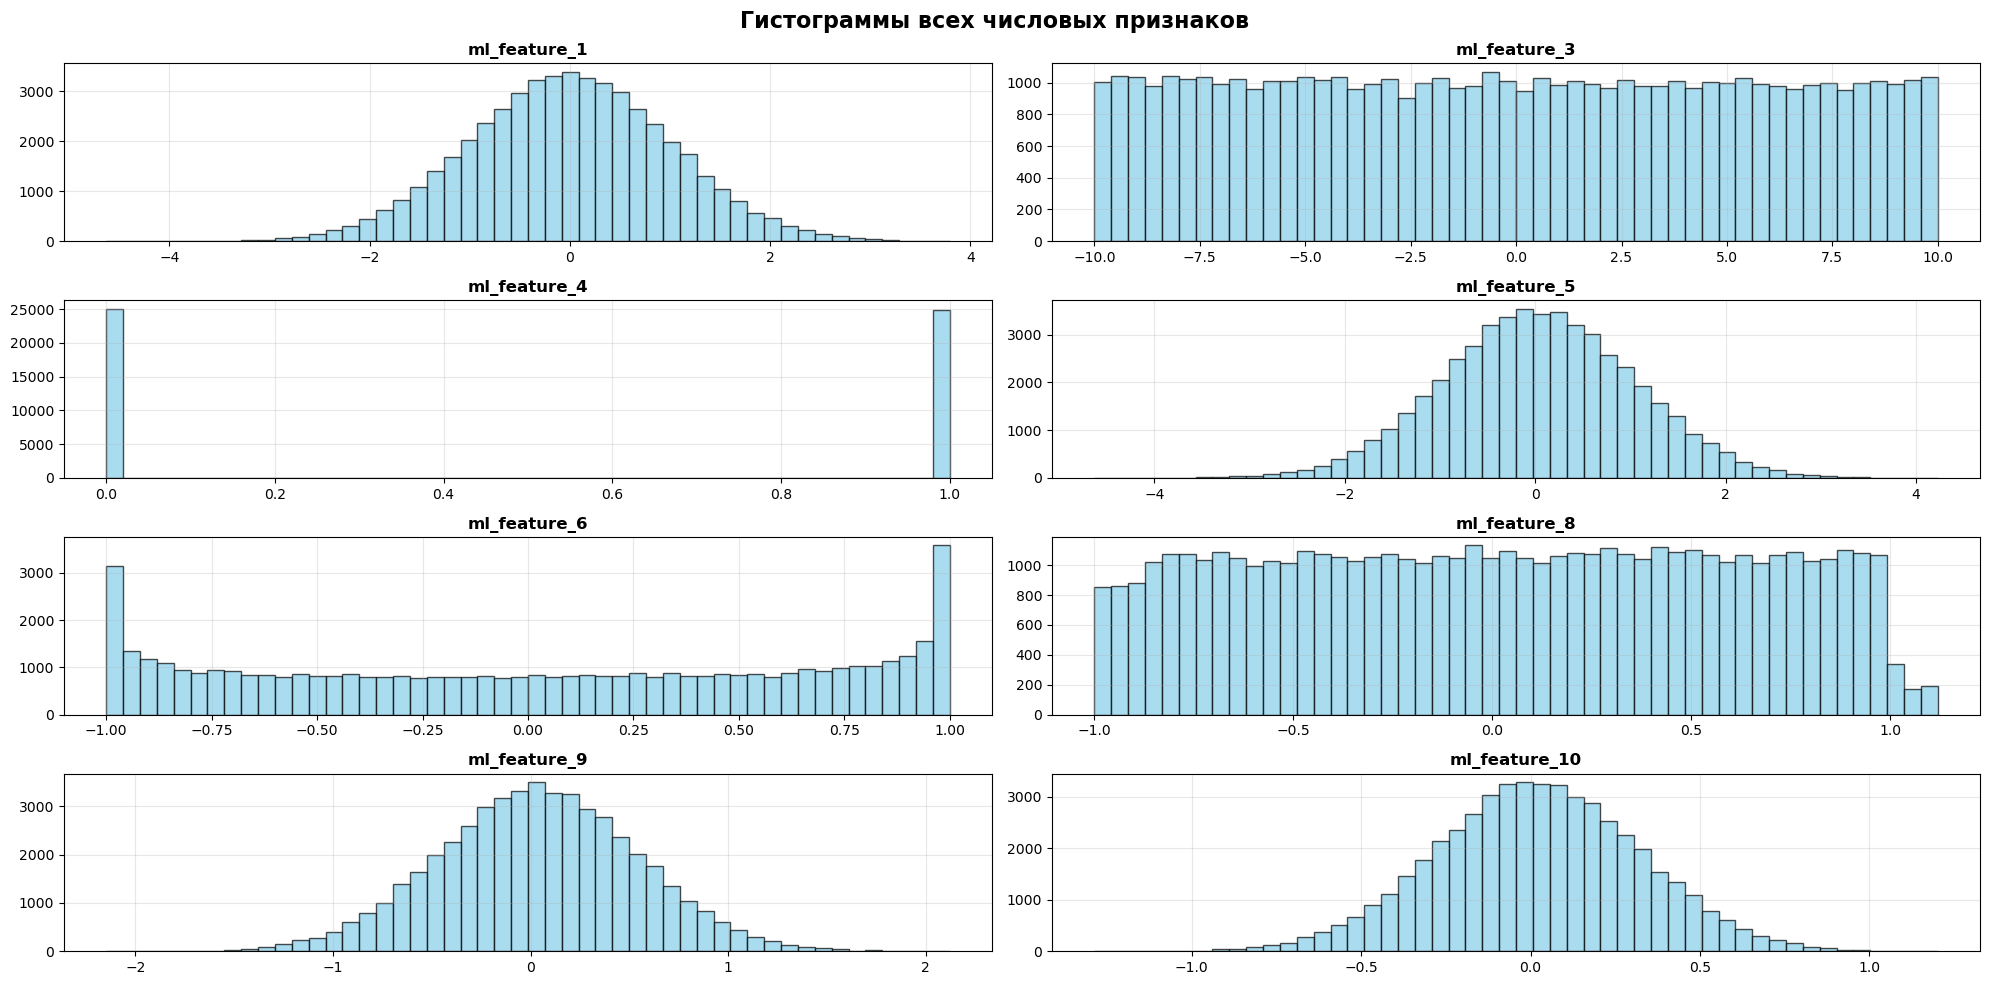

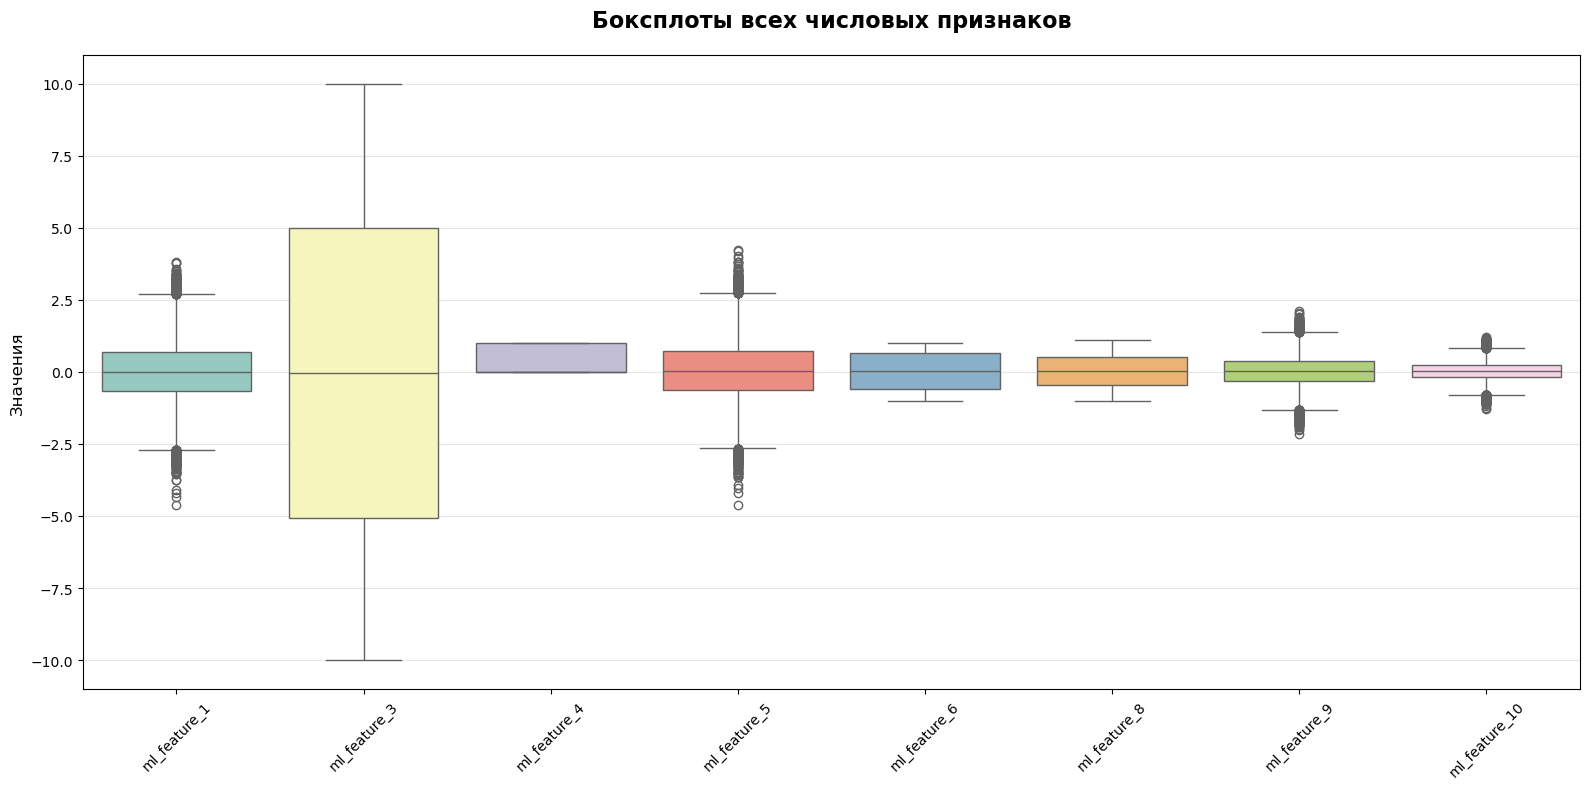

In [17]:
# Создаём компактную визуализацию всех признаков
fig, axes = plt.subplots(4, 2, figsize=(20, 10))
axes = axes.ravel()

for i, feature in enumerate(num):
    # Гистограмма
    axes[i].hist(df[feature].dropna(), bins=50, alpha=0.7, color='skyblue', edgecolor='black')
    axes[i].set_title(feature, fontweight='bold')
    axes[i].grid(True, alpha=0.3)

# Убираем пустые подграфики
for i in range(len(num), len(axes)):
    fig.delaxes(axes[i])

plt.suptitle('Гистограммы всех числовых признаков', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Боксплоты всех признаков вместе
plt.figure(figsize=(16, 8))
sns.boxplot(data=df[num], palette='Set3')
plt.title('Боксплоты всех числовых признаков', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, fontsize=10)
plt.ylabel('Значения', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

При анализе гистограмм, признак `ml_feature_4` явно не является непрерывным. Дополним анализ методом describe()

In [18]:
df[num].describe()

,ml_feature_1,ml_feature_3,ml_feature_4,ml_feature_5,ml_feature_6,ml_feature_8,ml_feature_9,ml_feature_10
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,-0.002445,-0.036381,0.498040,0.034729,0.022948,0.025465,0.035361,0.020226
std,1.000280,5.792335,0.500001,1.002116,0.656690,0.578026,0.505034,0.303309
min,-4.631262,-9.999742,0.000000,-4.631853,-1.000000,-0.999965,-2.147526,-1.287965
25%,-0.677784,-5.059555,0.000000,-0.639829,-0.579775,-0.470627,-0.304077,-0.182386
50%,-0.003776,-0.056155,0.000000,0.028112,0.037786,0.027348,0.035985,0.018930
75%,0.673534,4.985939,1.000000,0.707594,0.637131,0.521117,0.374152,0.224080
max,3.793828,9.999975,1.000000,4.230623,1.000000,1.119858,2.120786,1.202300


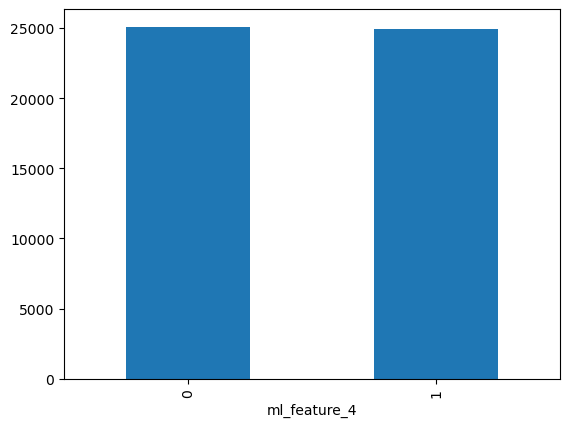

In [19]:
df['ml_feature_4'].value_counts().plot.bar()
plt.show()

`ml_feature_4` - дискретный признак

Выдвенем гипотезу, что время суток может влиять на вероятность клика. Для этого выделим из даты часы и разделим на категории по времени суток

In [20]:
datetime_col = pd.to_datetime(df['hour'], format='%y%m%d%H', errors='coerce')
df['day_of_week'] = datetime_col.dt.day_name()
df['hour_of_day'] = datetime_col.dt.hour

def get_time_of_day(hour):
    if 5 <= hour < 12:
        return 'Утро'
    elif 12 <= hour < 17:
        return 'День'
    elif 17 <= hour < 22:
        return 'Вечер'
    else:
        return 'Ночь'

df['time_of_day'] = df['hour_of_day'].apply(get_time_of_day)

In [21]:
df.head()

,click,hour,C1,banner_pos,site_category,app_domain,app_category,device_type,device_conn_type,C14,C15,C16,C17,C18,C19,C20,C21,ml_feature_1,ml_feature_2,ml_feature_3,ml_feature_4,ml_feature_5,ml_feature_6,ml_feature_7,ml_feature_8,ml_feature_9,ml_feature_10,day_of_week,hour_of_day,time_of_day
0,1,14102100,1005,1,f028772b,7801e8d9,07d7df22,1,0,17614,320,50,1993,2,1063,-1,33,-0.996823,A,0.666588,0,0.817292,0.993275,Z,-0.619959,0.433666,0.274038,Tuesday,0,Ночь
1,0,14102100,1005,0,28905ebd,7801e8d9,07d7df22,1,0,15701,320,50,1722,0,35,-1,79,-0.391309,C,5.146789,1,-0.883865,-0.825722,X,0.576526,-0.318558,-0.132851,Tuesday,0,Ночь
2,0,14102100,1005,0,f028772b,7801e8d9,07d7df22,1,0,17914,320,50,2043,2,39,100084,32,-2.112732,D,7.169348,0,-0.859440,-0.338365,Y,-0.440047,-0.345412,0.340487,Tuesday,0,Ночь
3,0,14102100,1005,0,50e219e0,d9b5648e,0f2161f8,1,0,21611,320,50,2480,3,297,100111,61,0.332707,A,-0.290708,1,0.062795,0.062934,Y,0.551982,0.733382,-0.198542,Tuesday,0,Ночь
4,0,14102100,1005,0,28905ebd,7801e8d9,07d7df22,1,0,15702,320,50,1722,0,35,100084,79,1.166623,A,6.319134,1,-0.675276,0.797144,X,0.640827,0.297955,-0.136909,Tuesday,0,Ночь


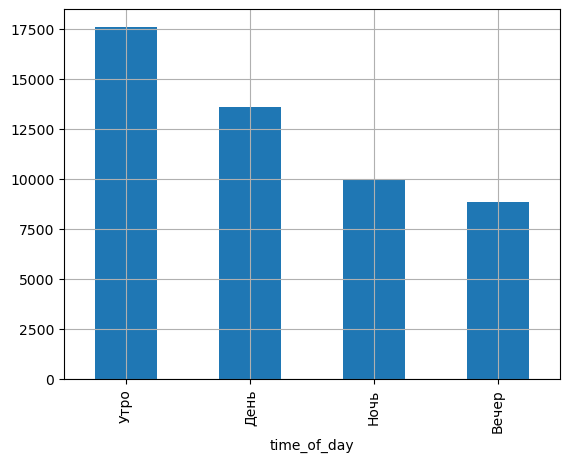

In [22]:
df['time_of_day'].value_counts().plot.bar()
plt.grid()
plt.show()

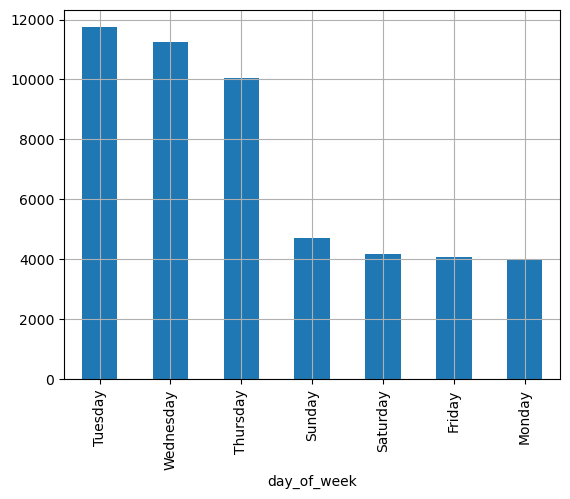

In [23]:
df['day_of_week'].value_counts().plot.bar()
plt.grid()
plt.show()

In [24]:
df = df.drop('hour', axis=1)
df = df.drop('hour_of_day', axis=1)

Отдельно изучим гистограмму признака С14

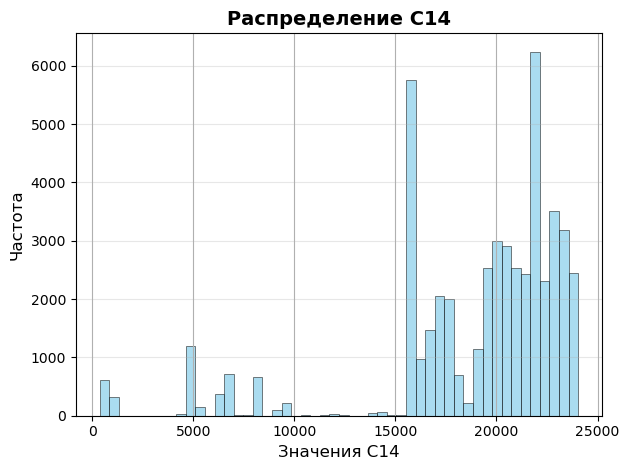

In [25]:
df['C14'].hist(
    bins=50,
    color='skyblue',
    alpha=0.7,
    edgecolor='black',
    linewidth=0.5
)
plt.title('Распределение C14', fontsize=14, fontweight='bold')
plt.xlabel('Значения C14', fontsize=12)
plt.ylabel('Частота', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

`ml_feature_1`, `ml_feature_5`, `ml_feature_9`, `ml_feature_10` - имеют нормальное распределение. 
`ml_feature_3`, `ml_feature_6`, `ml_feature_8` - распределение этих признаков не является нормальным, но при этом симметрично.
`ml_feature_4` - дискретный признак
`C14` - также не имеет нормального распределения, однако можно отметить области наиболее встречающихся значений. Гипотетически можем предполагать, что этот признак описывает габариты рекламы на странице. 

### Корреляции


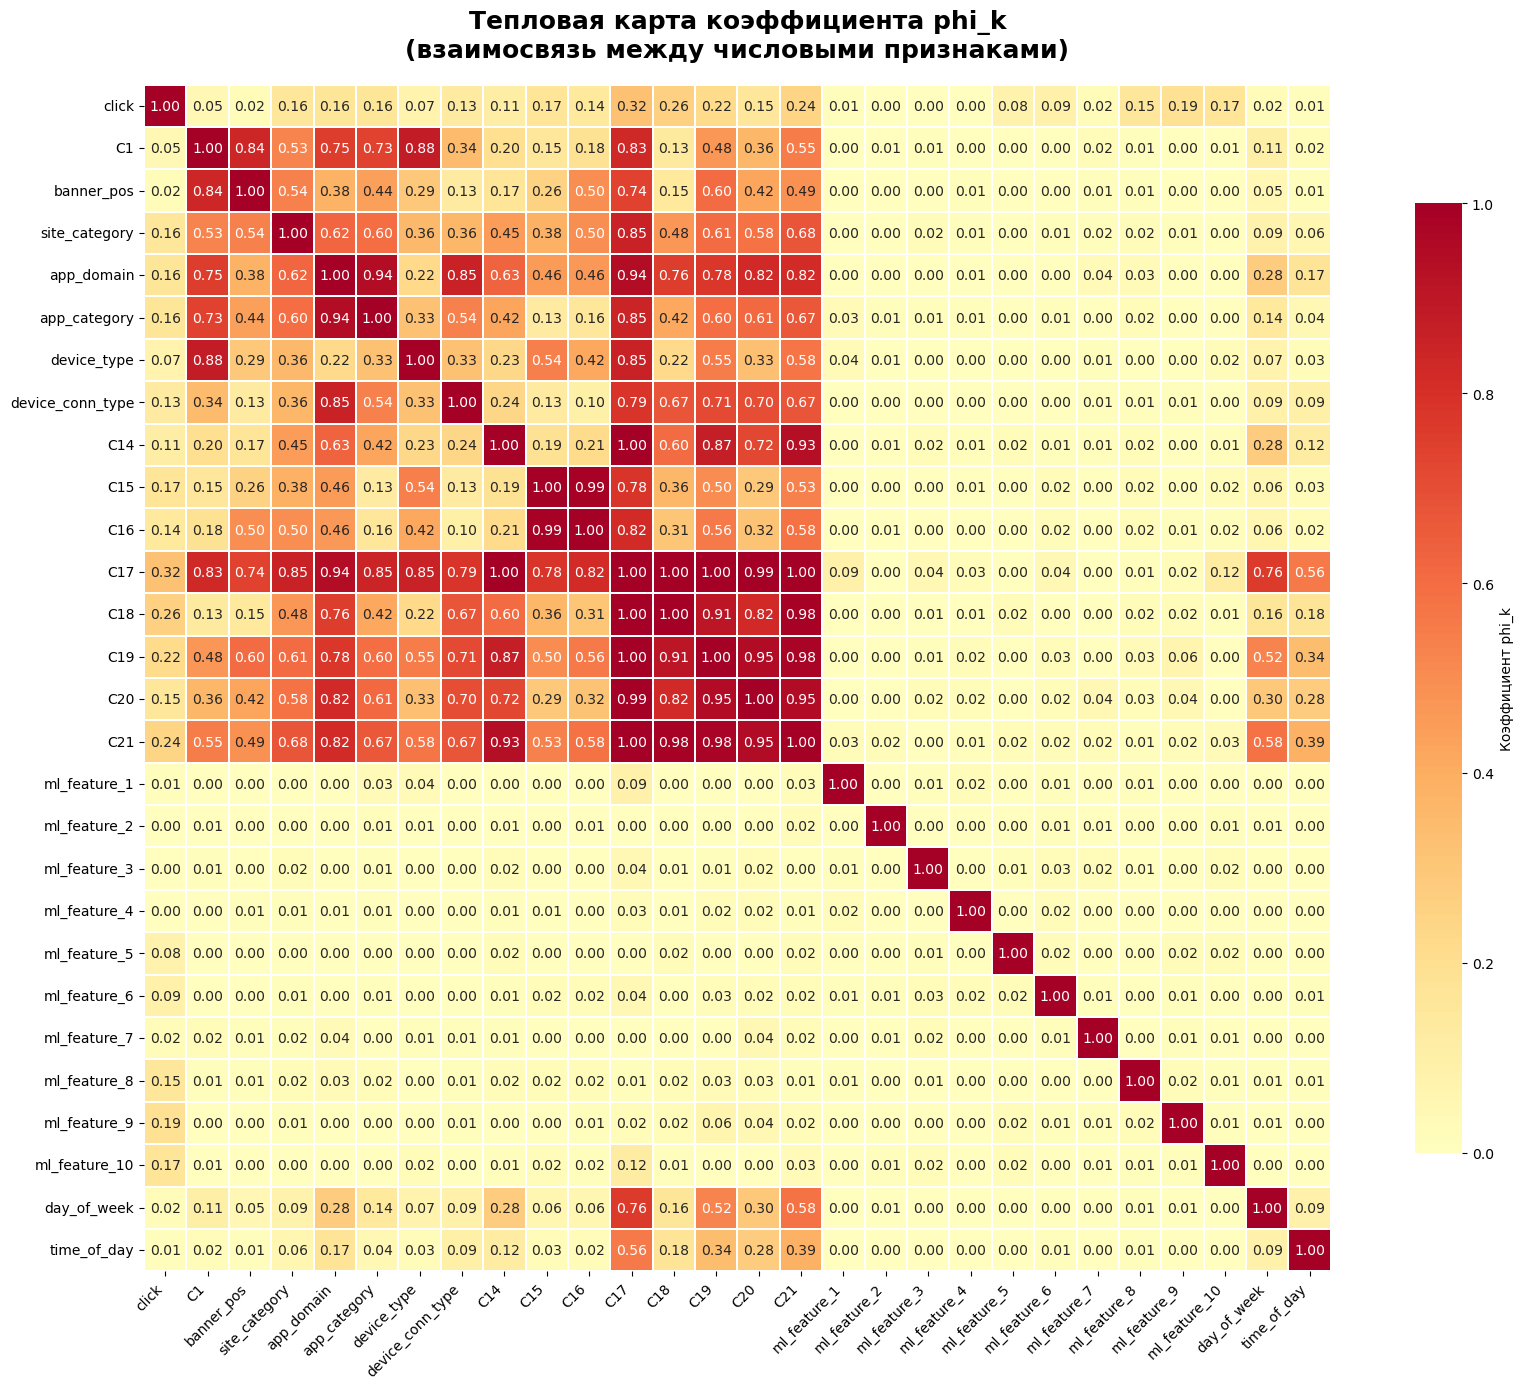

СИЛЬНЫЕ КОРРЕЛЯЦИИ (|phi_k| > 0.8):
C17 ↔ C21: 1.000
C17 ↔ C18: 1.000
C17 ↔ C19: 0.999
C14 ↔ C17: 0.999
C17 ↔ C20: 0.995
C15 ↔ C16: 0.992
C18 ↔ C21: 0.984
C19 ↔ C21: 0.979
C19 ↔ C20: 0.952
C20 ↔ C21: 0.951
app_domain ↔ C17: 0.943
app_domain ↔ app_category: 0.940
C14 ↔ C21: 0.934
C18 ↔ C19: 0.909
C1 ↔ device_type: 0.876
C14 ↔ C19: 0.870
app_domain ↔ device_conn_type: 0.855
device_type ↔ C17: 0.854
site_category ↔ C17: 0.852
app_category ↔ C17: 0.849
C1 ↔ banner_pos: 0.837
C1 ↔ C17: 0.830
app_domain ↔ C20: 0.824
C18 ↔ C20: 0.821
app_domain ↔ C21: 0.820
C16 ↔ C17: 0.817


In [26]:
# Вычисляем матрицу корреляций
correlation_matrix = df.phik_matrix(
    interval_cols=['ml_feature_1', 'ml_feature_3', 
                   'ml_feature_5', 'ml_feature_6', 
                   'ml_feature_8', 'ml_feature_9', 
                   'ml_feature_10', 'C14'
    ]
)

# Создаём фигуру с увеличенным размером
plt.figure(figsize=(18, 14))

# Тепловая карта с улучшенной читаемостью
heatmap = sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='RdYlBu_r',  # Красная-жёлтая-синяя палитра (обратная)
    center=0,  # Центрируем цветовую шкалу на 0
    linewidths=0.3,
    linecolor='white',  # Цвет линий между ячейками
    cbar=True,  # Показываем цветовую шкалу
    cbar_kws={'label': 'Коэффициент phi_k', 'shrink': 0.8},
    square=True,
    annot_kws={'size': 10}  # Размер шрифта аннотаций
)

# Настройка заголовка
plt.title(
    'Тепловая карта коэффициента phi_k\n(взаимосвязь между числовыми признаками)',
    fontsize=18,
    fontweight='bold',
    pad=20
)

# Поворот меток осей для лучшей читаемости
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

# Оптимизация расположения элементов
plt.tight_layout()
plt.show()


print("СИЛЬНЫЕ КОРРЕЛЯЦИИ (|phi_k| > 0.8):")
strong_corr = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i + 1, len(correlation_matrix.columns)):
        corr_value = correlation_matrix.iloc[i, j]
        if abs(corr_value) > 0.8:
            strong_corr.append((
                correlation_matrix.columns[i],
                correlation_matrix.columns[j],
                corr_value
            ))

if strong_corr:
    for col1, col2, corr in sorted(strong_corr, key=lambda x: abs(x[2]), reverse=True):
        print(f"{col1} ↔ {col2}: {corr:.3f}")
else:
    print("Сильных корреляций не обнаружено")

**Анализ корреляций phi_k (|phi_k| > 0.8) показывает выраженную избыточность признаков и несколько ключевых кластеров взаимосвязей.**  

**1. Центральный узел — C17
C17 выступает главным «хабом» в сети корреляций:**

- имеет полную или почти полную корреляцию с C18, C19, C20, C21 (|phi_k| ≥ 0.995);

- сильно связан с C14 (0.999), C16 (0.817);

- коррелирует с внешними признаками: app_domain (0.943), app_category (0.849), device_type (0.854), site_category (0.852).

Вывод: C17, скорее всего, дублирует или почти полностью определяет значения других Cxx-признаков.

**2. Группа высококоррелирующих C
Формируется единый кластер из признаков C14, C15, C16, C17, C18, C19, C20, C21:**

- внутри группы корреляции очень высокие (от 0.817 до 1.000);

- ключевые связи: C17 ↔ C21 = 1.000, C17 ↔ C18 = 1.000, C19 ↔ C20 = 0.952, C20 ↔ C21 = 0.951.

Вывод: эти признаки несут практически одинаковую информацию.

**3. Кластер app_domain
app_domain образует отдельный значимый кластер:**

- сильная связь с app_category (0.940);

- высокие корреляции с C17 (0.943), C20 (0.824), C21 (0.820);

- связь с device_conn_type (0.855).

Вывод: app_domain, вероятно, кодирует ту же сущность, что и app_category, либо жёстко с ней связан.

**4. Локальные пары и триады**
- C15 ↔ C16: 0.992 — почти полное дублирование;

- C18 ↔ C19: 0.909 — очень сильная связь;

- C1 ↔ device_type: 0.876, C1 ↔ banner_pos: 0.837 — отдельный мини‑кластер.

**5. Потенциальные проблемы для моделирования**
- Мультиколлинеарность. Высокая корреляция исказит веса в линейных моделях и снизит их устойчивость.

- Избыточность. Дублирующие признаки не добавляют новой информации, но увеличивают размерность данных.

- Риск переобучения. Сложные модели (деревья решений, нейросети) могут «запомнить» шум в коррелирующих признаках.

- Замедление обучения. Большое число коррелирующих признаков увеличивает время обучения и потребление памяти.

### Выводы по EDA  

**1. Общая характеристика датасета**  
- Объём: 50 000 строк, 34 столбца.  
- Пропуски: отсутствуют 
- Дубликаты: отсутствуют

**Типы данных:**

- float64 — 8 столбцов;  
- int64 — 15 столбцов;  
- object — 11 столбцов.

**Целевая переменная (click):**  

- 0 (не кликнули) — 41 397 записей (82,79 %);  
- 1 (кликнули) — 8 603 записи (17,21 %).

**2. Проблемы в данных**
- Дисбаланс классов (83 % против 17 %) — требует использования метрик, устойчивых к дисбалансу: F1‑score, Precision, Recall, PR‑AUC, Log Loss.  
- Высокая кардинальность у ряда признаков — риск переобучения и избыточности: `device_ip`, `device_id`, `site_id`, `app_id`, `device_model`, `app_domain`.  
- Мультиколлинеарность — сильные корреляции между признаками искажают веса в линейных моделях и снижают их устойчивость.  
- Избыточность — дублирование информации в признаках увеличивает размерность без добавления ценности.

**3. Признаки**  

- Признаки, не несущие полезной информации для обучения модели были выявлены и удалены
- Изучены числовые и категориальные признаки
- Построены гистограммы и изучено распределение числовых признаков
- Изучены категориальные признаки.
- Категориальные признаки, в записи которых только числа, приведены к нужному типу данных

**4. Добавление новых данных**

- Добавлен новый признак, характеризующий время суток
- Удалены идентификационные признаки
- Удалены мультиколлинеарные признаки

##  Разделение данных на выборки

### Разделение данных


In [27]:
X = df.drop('click', axis=1)
y = df['click']

In [28]:
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, 
                                                            test_size=0.2, 
                                                            shuffle=True, 
                                                            random_state = RANDOM_SEED,
                                                            stratify=y)

### Анализ корреляций на тренировочных данных

Text(0.5, 1.0, 'Тепловая карта коэффициента phi_k\n(взаимосвязь между числовыми признаками)')

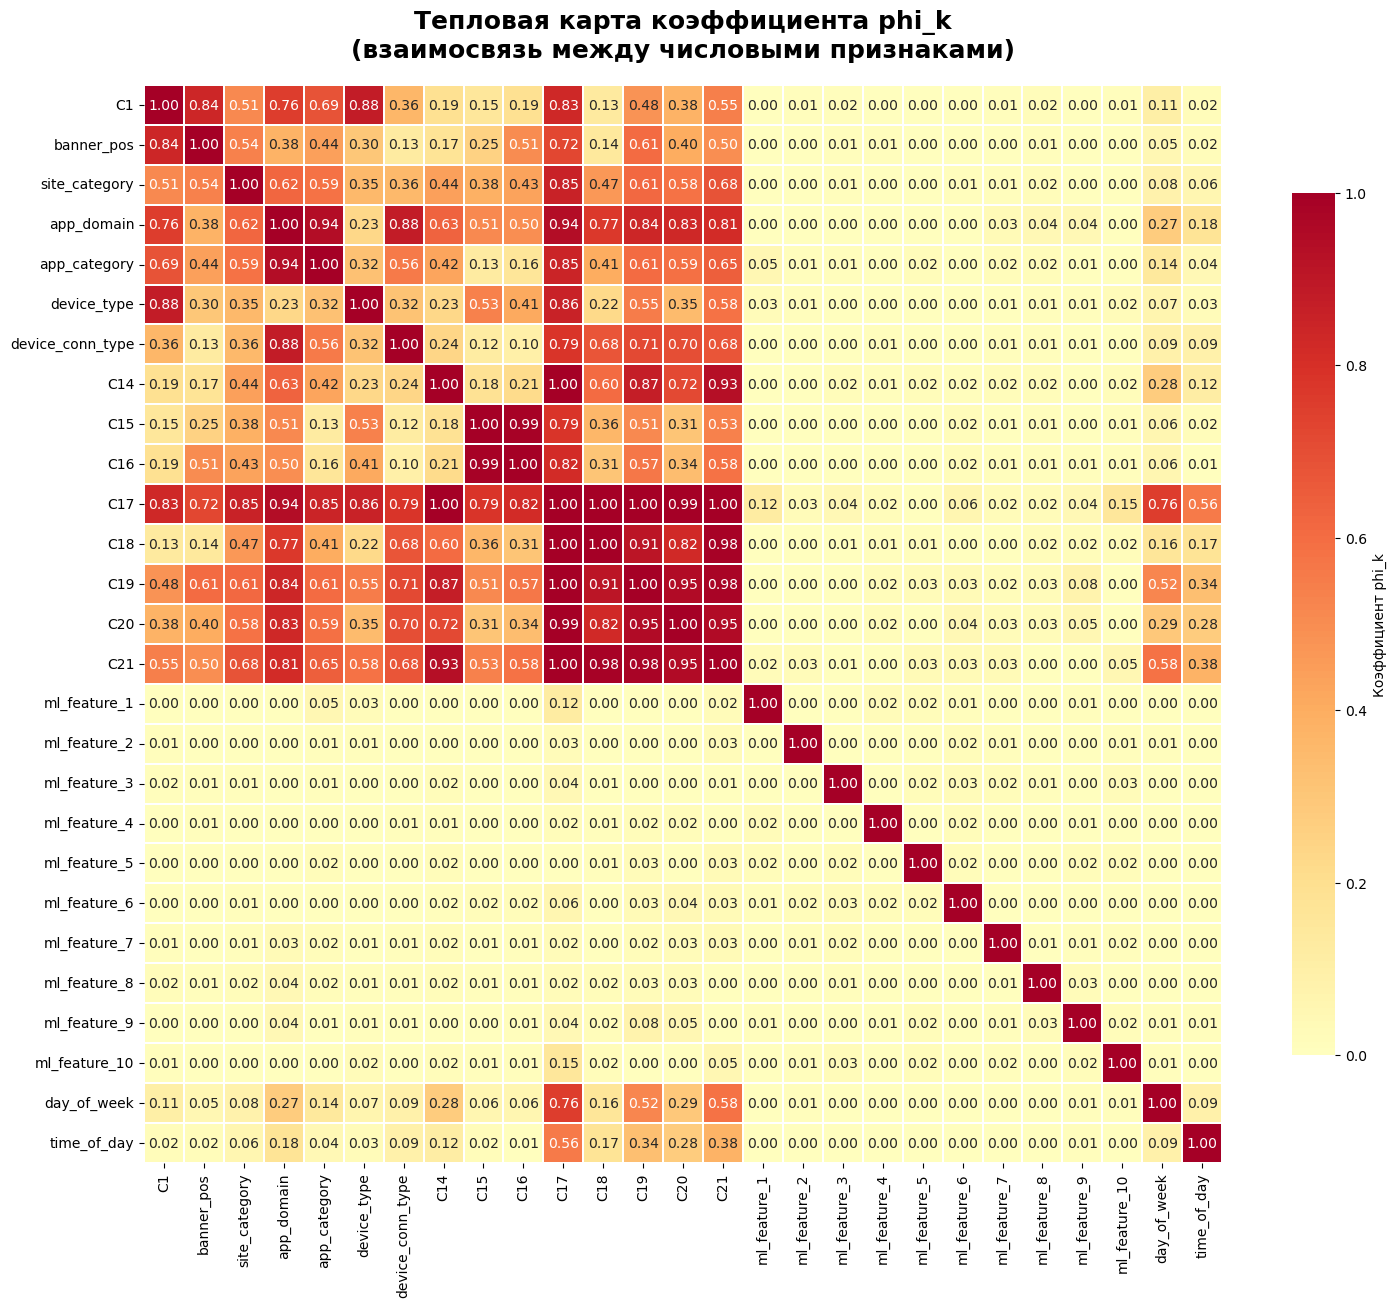

In [29]:
# Вычисляем матрицу корреляций
correlation_matrix_train = X_train_val.phik_matrix(
    interval_cols=['ml_feature_1', 'ml_feature_3', 
                   'ml_feature_5', 'ml_feature_6', 
                   'ml_feature_8', 'ml_feature_9', 
                   'ml_feature_10', 'C14'
    ]
)

# Создаём фигуру с увеличенным размером
plt.figure(figsize=(18, 14))

# Тепловая карта с улучшенной читаемостью
heatmap = sns.heatmap(
    correlation_matrix_train,
    annot=True,
    fmt='.2f',
    cmap='RdYlBu_r',  # Красная-жёлтая-синяя палитра (обратная)
    center=0,  # Центрируем цветовую шкалу на 0
    linewidths=0.3,
    linecolor='white',  # Цвет линий между ячейками
    cbar=True,  # Показываем цветовую шкалу
    cbar_kws={'label': 'Коэффициент phi_k', 'shrink': 0.8},
    square=True,
    annot_kws={'size': 10}  # Размер шрифта аннотаций
)

# Настройка заголовка
plt.title(
    'Тепловая карта коэффициента phi_k\n(взаимосвязь между числовыми признаками)',
    fontsize=18,
    fontweight='bold',
    pad=20)


Подтверждаем мультиколлинеарные признаки на тренировочной выборке

In [30]:
columns_to_drop_c = ['C14', 'C15', 'C16', 'C18', 'C19', 'C20', 'C21', 'app_domain']
X_train_val = X_train_val.drop(columns=columns_to_drop_c)


### Проверьте разделение
- Убедитесь, что распределение целевой переменной сохранено в каждой выборке.
- Выведите размеры выборок.

In [31]:
# Проверка размеров выборок
print("РАЗМЕРЫ ВЫБОРОК")
print(f"Общий размер датасета: {len(df)} записей")
print(f"Размер обучающей выборки: {X_train_val.shape[0]} записей ({X_train_val.shape[0]/len(df)*100:.1f} % от общего)")
print(f"Размер тестовой выборки: {X_test.shape[0]} записей ({X_test.shape[0]/len(df)*100:.1f} % от общего)")

# Проверка распределения целевой переменной в обучающей выборке
train_click_0 = (y_train_val == 0).sum()
train_click_1 = (y_train_val == 1).sum()
train_ratio_0 = train_click_0 / len(y_train_val)
train_ratio_1 = train_click_1 / len(y_train_val)

print("\nРАСПРЕДЕЛЕНИЕ ЦЕЛЕВОЙ ПЕРЕМЕННОЙ В ОБУЧАЮЩЕЙ ВЫБОРКЕ")
print(f"Не кликнули (click = 0): {train_click_0} записей ({train_ratio_0*100:.2f} %)")
print(f"Кликнули (click = 1): {train_click_1} записей ({train_ratio_1*100:.2f} %)")

# Проверка распределения целевой переменной в тестовой выборке
test_click_0 = (y_test == 0).sum()
test_click_1 = (y_test == 1).sum()
test_ratio_0 = test_click_0 / len(y_test)
test_ratio_1 = test_click_1 / len(y_test)

print("\nРАСПРЕДЕЛЕНИЕ ЦЕЛЕВОЙ ПЕРЕМЕННОЙ В ТЕСТОВОЙ ВЫБОРКЕ")
print(f"Не кликнули (click = 0): {test_click_0} записей ({test_ratio_0*100:.2f} %)")
print(f"Кликнули (click = 1): {test_click_1} записей ({test_ratio_1*100:.2f} %)")



РАЗМЕРЫ ВЫБОРОК
Общий размер датасета: 50000 записей
Размер обучающей выборки: 40000 записей (80.0 % от общего)
Размер тестовой выборки: 10000 записей (20.0 % от общего)

РАСПРЕДЕЛЕНИЕ ЦЕЛЕВОЙ ПЕРЕМЕННОЙ В ОБУЧАЮЩЕЙ ВЫБОРКЕ
Не кликнули (click = 0): 33118 записей (82.80 %)
Кликнули (click = 1): 6882 записей (17.21 %)

РАСПРЕДЕЛЕНИЕ ЦЕЛЕВОЙ ПЕРЕМЕННОЙ В ТЕСТОВОЙ ВЫБОРКЕ
Не кликнули (click = 0): 8279 записей (82.79 %)
Кликнули (click = 1): 1721 записей (17.21 %)


## Предобработка данных — построение пайплайнов

### Создаём пайплайн для предобработки данных


In [32]:
cat_OHE = ['ml_feature_2', 
           'ml_feature_7', 'C1', 'banner_pos', 'device_type',
           'device_conn_type', 'time_of_day', 'day_of_week']
cat_TE = ['C17', 'site_category','app_category']
num_col = ['ml_feature_1', 'ml_feature_3', 'ml_feature_4',
           'ml_feature_5', 'ml_feature_6', 'ml_feature_8', 
           'ml_feature_9', 'ml_feature_10']

#Создаём пайпланы:
#Для числовых признаков
num_pipeline = Pipeline(steps = [
    ('обработка пропусков', SimpleImputer(strategy = 'median')),
    ('масштабирование', StandardScaler())
])

#Для категориальных
cat_pipeline_OHE = Pipeline(steps=[
    ('обработка пропусков', SimpleImputer(strategy = 'constant', fill_value= 'missing')),
    ('кодирование признаков', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
])

cat_pipeline_TE = Pipeline(steps=[
    ('обработка пропусков', SimpleImputer(strategy = 'constant', fill_value= 'missing')),
    ('кодирование признаков', TargetEncoder())
])

### Объедините пайплайны
- Используйте `sklearn.pipeline.Pipeline` и `ColumnTransformer`.
- **Важно:** используйте информацию о пропусках и категориях только из обучающей выборки!

In [33]:
# Объединяем все пайплайны в один ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    ('num', num_pipeline, num_col),
    ('cat_OHE', cat_pipeline_OHE, cat_OHE),
    ('cat_TE', cat_pipeline_TE, cat_TE)],
remainder='drop'
)

## Отбор признаков

### Применяем фильтрационные методы

Применим методы фильтрации и метод-обёртку для отбора наиболее информативных признаков

In [34]:
preprocessor.fit(X_train_val, y_train_val)
X_train_val_transformed = pd.DataFrame(preprocessor.transform(X_train_val), columns=preprocessor.get_feature_names_out())
transformed_col_names = []

for column in preprocessor.get_feature_names_out():
    transformed_col_names.append(column[column.index('__') + 2:])

In [35]:
mi_scores = mutual_info_classif(X_train_val_transformed, y_train_val)
mi_scores = pd.Series(mi_scores, index=transformed_col_names)
mi_scores= mi_scores.sort_values(ascending=False).head(15)
print('Топ 15 признаков')
print(mi_scores)

Топ 15 признаков
C17                   0.039006
ml_feature_8          0.027220
app_category          0.016006
ml_feature_9          0.011782
ml_feature_10         0.009317
C1_1005               0.006776
device_conn_type_0    0.006725
banner_pos_0          0.006035
site_category         0.005936
device_type_1         0.005692
ml_feature_6          0.005077
ml_feature_7_Z        0.004980
ml_feature_4          0.004407
banner_pos_5          0.004374
device_conn_type_3    0.003596
dtype: float64


Сделаем проверку на квази-константные признаки:

In [36]:
# Выделим квази-константные признаки 
vs_quasi = VarianceThreshold(threshold=0.05) # Среди числовых значений
vs_quasi.fit(X_train_val[num_col])
quasi_num_cols = [col for col, keep in zip(num_col, vs_quasi.get_support()) if not keep]

all_cat_features = [col for col in X_train_val.columns if col not in num_col] # Среди категорильных значений
quasi_cat_cols = [col for col in all_cat_features if X_train_val[col].value_counts(normalize=True).max() > 0.9]

# Результат 
quasi_cols = quasi_num_cols + quasi_cat_cols
print("Квази-константные признаки для удаления:", quasi_cols)

Квази-константные признаки для удаления: ['C1', 'device_type']


### Применяем методы-обёртки


Запуск Recursive Feature Elimination (RFE) из sklearn...
Подбор оптимального количества признаков с помощью кросс-валидации...


Перебор числа признаков: 100%|███████████████████████████████████████████████████████████| 8/8 [00:29<00:00,  3.66s/it]



Оптимальное количество признаков: 19 (F1-score: 0.1524)

Запуск финального RFE с 19 признаками...
Fitting estimator with 52 features.
Fitting estimator with 51 features.
Fitting estimator with 50 features.
Fitting estimator with 49 features.
Fitting estimator with 48 features.
Fitting estimator with 47 features.
Fitting estimator with 46 features.
Fitting estimator with 45 features.
Fitting estimator with 44 features.
Fitting estimator with 43 features.
Fitting estimator with 42 features.
Fitting estimator with 41 features.
Fitting estimator with 40 features.
Fitting estimator with 39 features.
Fitting estimator with 38 features.
Fitting estimator with 37 features.
Fitting estimator with 36 features.
Fitting estimator with 35 features.
Fitting estimator with 34 features.
Fitting estimator with 33 features.
Fitting estimator with 32 features.
Fitting estimator with 31 features.
Fitting estimator with 30 features.
Fitting estimator with 29 features.
Fitting estimator with 28 features.
F

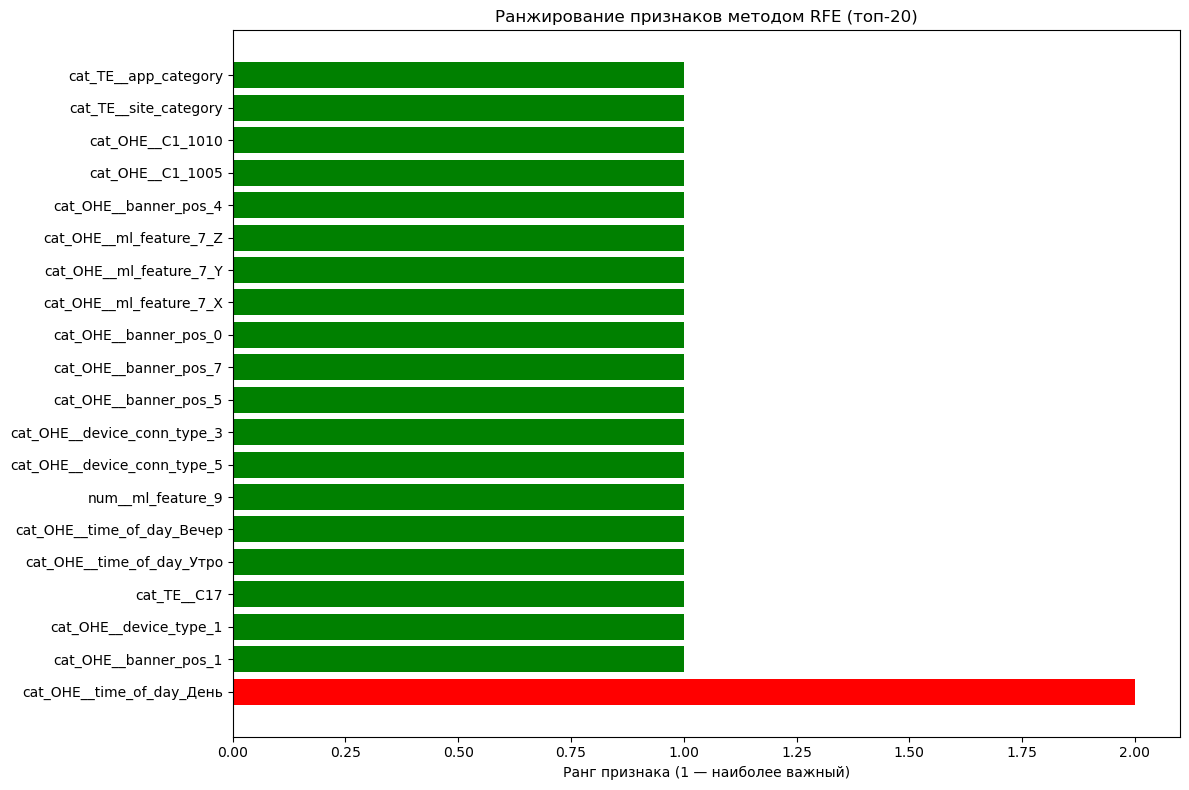


ДОПОЛНИТЕЛЬНАЯ СТАТИСТИКА:
Всего признаков: 52
Отобрано признаков: 19
Удалено признаков: 33

Распределение рангов:
Ранг 1: 19 признаков
Ранг 2: 1 признаков
Ранг 3: 1 признаков
Ранг 4: 1 признаков
Ранг 5: 1 признаков
Ранг 6: 1 признаков
Ранг 7: 1 признаков
Ранг 8: 1 признаков
Ранг 9: 1 признаков
Ранг 10: 1 признаков
Ранг 11: 1 признаков
Ранг 12: 1 признаков
Ранг 13: 1 признаков
Ранг 14: 1 признаков
Ранг 15: 1 признаков
Ранг 16: 1 признаков
Ранг 17: 1 признаков
Ранг 18: 1 признаков
Ранг 19: 1 признаков
Ранг 20: 1 признаков
Ранг 21: 1 признаков
Ранг 22: 1 признаков
Ранг 23: 1 признаков
Ранг 24: 1 признаков
Ранг 25: 1 признаков
Ранг 26: 1 признаков
Ранг 27: 1 признаков
Ранг 28: 1 признаков
Ранг 29: 1 признаков
Ранг 30: 1 признаков
Ранг 31: 1 признаков
Ранг 32: 1 признаков
Ранг 33: 1 признаков
Ранг 34: 1 признаков
--------------------------------------------------


In [37]:

print("Запуск Recursive Feature Elimination (RFE) из sklearn...")

# Параметры для подбора оптимального числа признаков
feature_counts = range(5, 21, 2)  # тестируем от 5 до 20 признаков с шагом 2
cv_scores = []

print("Подбор оптимального количества признаков с помощью кросс-валидации...")

for n_features in tqdm(feature_counts, desc="Перебор числа признаков"):
    try:
        # Создаём и настраиваем RFE
        rfe_selector = RFE(
            estimator=LogisticRegression(solver='liblinear', random_state=42),
            n_features_to_select=n_features,
            step=1,
            verbose=0
        )
        
        # Обучаем RFE на обучающих данных
        rfe_selector.fit(X_train_val_transformed, y_train_val)
        
        # Получаем выбранные признаки
        selected_features = X_train_val_transformed.columns[rfe_selector.support_]
        X_selected = X_train_val_transformed[selected_features]
        
        # Кросс-валидация для оценки качества
        cv_score = cross_val_score(
            LogisticRegression(solver='liblinear', random_state=42),
            X_selected, y_train_val,
            cv=5, scoring='f1'
        ).mean()
        cv_scores.append(cv_score)
    except Exception as e:
        print(f"Ошибка при n_features={n_features}: {e}")
        cv_scores.append(0)

# Определяем оптимальное число признаков
optimal_n_features = feature_counts[np.argmax(cv_scores)]
print(f"\nОптимальное количество признаков: {optimal_n_features} (F1-score: {max(cv_scores):.4f})")

# Запускаем финальный RFE с оптимальным числом признаков
print(f"\nЗапуск финального RFE с {optimal_n_features} признаками...")
rfe_final = RFE(
    estimator=LogisticRegression(solver='liblinear', random_state=42),
    n_features_to_select=optimal_n_features,
    step=1,
    verbose=1
)
rfe_final.fit(X_train_val_transformed, y_train_val)

# Получаем информацию о выбранных признаках
selected_rfe_features = X_train_val_transformed.columns[rfe_final.support_].tolist()
print(f'\nВыбранные признаки RFE ({optimal_n_features}): {selected_rfe_features}')

# Создаём DataFrame с ранжированием признаков
ranking_df = pd.DataFrame({
    'feature': X_train_val_transformed.columns,
    'rank': rfe_final.ranking_,
    'selected': rfe_final.support_
}).sort_values('rank')

print(f'\nРанжирование признаков RFE:')
print(ranking_df)

# Сохраняем результаты в CSV
ranking_df.to_csv('rfe_feature_ranking.csv', index=False)
print("\nРезультаты сохранены в 'rfe_feature_ranking.csv'")

# Визуализация ранжирования
plt.figure(figsize=(12, 8))
top_features = ranking_df.head(20)  # топ-20 для наглядности
colors = ['green' if x else 'red' for x in top_features['selected']]
plt.barh(top_features['feature'], top_features['rank'], color=colors)
plt.xlabel('Ранг признака (1 — наиболее важный)')
plt.title('Ранжирование признаков методом RFE (топ-20)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('rfe_ranking_plot.png', dpi=300, bbox_inches='tight')
plt.show()

# Дополнительная статистика
print("\n" + "="*50)
print("ДОПОЛНИТЕЛЬНАЯ СТАТИСТИКА:")
print("="*50)
selected_count = ranking_df['selected'].sum()
total_count = len(ranking_df)
print(f"Всего признаков: {total_count}")
print(f"Отобрано признаков: {selected_count}")
print(f"Удалено признаков: {total_count - selected_count}")

# Анализ распределения рангов
rank_distribution = ranking_df['rank'].value_counts().sort_index()
print("\nРаспределение рангов:")
for rank, count in rank_distribution.items():
    print(f"Ранг {rank}: {count} признаков")

print("-" * 50)

### Выбераем финальный набор признаков


In [38]:
# Признаки из метода фильтрации (топ‑15) с их MI
filter_features_with_scores = [
    ('C17', 0.037083),
    ('ml_feature_8', 0.027220),
    ('app_category', 0.012322),
    ('ml_feature_9', 0.011782),
    ('ml_feature_10', 0.009317),
    ('device_conn_type_0', 0.007751),
    ('site_category', 0.007136),
    ('ml_feature_4', 0.006705),
    ('ml_feature_7_Z', 0.006113),
    ('banner_pos_0', 0.005734),
    ('device_type_1', 0.005676),
    ('ml_feature_6', 0.005077),
    ('C1_1005', 0.004258),
    ('device_conn_type_3', 0.004237),
    ('day_of_week_Friday', 0.003963)
]

# Признаки из RFE с рангом 1 (selected=True)
rfe_selected_features = {
    'cat_TE__app_category', 'cat_TE__site_category',
    'cat_OHE__C1_1010', 'cat_OHE__C1_1008', 'cat_OHE__C1_1005',
    'cat_OHE__banner_pos_4', 'cat_OHE__ml_feature_7_Z',
    'cat_OHE__ml_feature_7_Y', 'cat_OHE__ml_feature_7_X',
    'cat_OHE__banner_pos_0', 'cat_OHE__banner_pos_7',
    'cat_OHE__banner_pos_1', 'cat_OHE__device_conn_type_3',
    'cat_OHE__device_conn_type_5', 'num__ml_feature_9',
    'cat_OHE__time_of_day_Вечер', 'cat_OHE__time_of_day_Утро',
    'cat_TE__C17', 'cat_OHE__device_type_1'
}


In [39]:
def normalize_feature_name(name):
    if '__' in name:
        return name.split('__', 1)[1]
    return name

rfe_normalized = {normalize_feature_name(f) for f in rfe_selected_features}


In [40]:
feature_ranking = []

# Добавляем признаки из фильтрации с весами
for feature, mi_score in filter_features_with_scores:
    if feature in rfe_normalized:
        weight = 3
        reason = "Оба метода"
    else:
        weight = 2
        reason = "Только фильтрация"
    feature_ranking.append((feature, mi_score, weight, reason))

# Добавляем признаки только из RFE
for feature in rfe_normalized:
    if not any(f[0] == feature for f in feature_ranking):
        feature_ranking.append((feature, 0, 1, "Только RFE"))

# Сортируем: сначала по весу, затем по MI
feature_ranking.sort(key=lambda x: (x[2], x[1]), reverse=True)


In [41]:
final_features = []
count = 0

for feature, mi, weight, reason in feature_ranking:
    if count >= 15: 
        break
    # Исключаем признаки с очень низкой MI, если есть альтернативы
    if weight == 1 and mi < 0.003:  # порог для «только RFE»
        continue
    final_features.append(feature)
    count += 1

print("ИТОГОВЫЙ НАБОР ПРИЗНАКОВ (15 шт.):")
print("==" * 50)
for i, feature in enumerate(final_features, 1):
    # Находим исходные данные для отображения
    mi_score = next((mi for f, mi, _, _ in feature_ranking if f == feature), 0)
    weight = next((w for f, _, w, _ in feature_ranking if f == feature), 1)
    reason = next((r for f, _, _, r in feature_ranking if f == feature), "RFE")
    print(f"{i:2d}. {feature:<25} | MI: {mi_score:.5f} | Вес: {weight} | {reason}")


ИТОГОВЫЙ НАБОР ПРИЗНАКОВ (15 шт.):
 1. C17                       | MI: 0.03708 | Вес: 3 | Оба метода
 2. app_category              | MI: 0.01232 | Вес: 3 | Оба метода
 3. ml_feature_9              | MI: 0.01178 | Вес: 3 | Оба метода
 4. site_category             | MI: 0.00714 | Вес: 3 | Оба метода
 5. ml_feature_7_Z            | MI: 0.00611 | Вес: 3 | Оба метода
 6. banner_pos_0              | MI: 0.00573 | Вес: 3 | Оба метода
 7. device_type_1             | MI: 0.00568 | Вес: 3 | Оба метода
 8. C1_1005                   | MI: 0.00426 | Вес: 3 | Оба метода
 9. device_conn_type_3        | MI: 0.00424 | Вес: 3 | Оба метода
10. ml_feature_8              | MI: 0.02722 | Вес: 2 | Только фильтрация
11. ml_feature_10             | MI: 0.00932 | Вес: 2 | Только фильтрация
12. device_conn_type_0        | MI: 0.00775 | Вес: 2 | Только фильтрация
13. ml_feature_4              | MI: 0.00671 | Вес: 2 | Только фильтрация
14. ml_feature_6              | MI: 0.00508 | Вес: 2 | Только фильтрация
15. da

In [42]:
final_features = ['C17','app_category','site_category',
                  'banner_pos', 'device_type', 'C1', 'device_conn_type',  
                  'ml_feature_4', 'ml_feature_6', 'ml_feature_7',
                  'ml_feature_8', 'ml_feature_9', 'ml_feature_10', 'day_of_week']


In [43]:
X = df[final_features]
y = df['click']

In [44]:
#Обновим категории
cat_OHE = ['ml_feature_7', 'C1', 'banner_pos', 'device_type',
           'device_conn_type', 'day_of_week']
cat_TE = ['C17', 'site_category','app_category',]
num_col = [ 'ml_feature_4', 'ml_feature_6', 'ml_feature_8', 
           'ml_feature_9', 'ml_feature_10']

# Объединяем все пайплайны в один ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    ('num', num_pipeline, num_col),
    ('cat_OHE', cat_pipeline_OHE, cat_OHE),
    ('cat_TE', cat_pipeline_TE, cat_TE)],
remainder='drop'
)

In [45]:
X_train_val_calib, X_test, y_train_val_calib, y_test = train_test_split(X, 
                                                            y, 
                                                            test_size=0.2, 
                                                            shuffle=True, 
                                                            random_state=RANDOM_SEED,
                                                            stratify=y)

X_train_val, X_calib, y_train_val, y_calib = train_test_split(X_train_val_calib, 
                                                              y_train_val_calib, 
                                                              test_size=15/80, 
                                                              stratify=y_train_val_calib) 
print(X_train_val.shape, X_test.shape, y_train_val.shape, y_test.shape)


(32500, 14) (10000, 14) (32500,) (10000,)


**Вывод по главе**

В ходе проделанной работы были проанализированы на предмет важности все признаки. Отобрано 14 признаков, оказывающие наибольшее влияние на целевую переменную. Датасет обновлен. Итоговое количество признаков: 14.

## Обучение базовой модели

### Обучаем `DummyClassifier`


In [46]:
cv = StratifiedKFold(n_splits=5, random_state=RANDOM_SEED, shuffle=True)

In [47]:
scoring = ['average_precision', 'precision', 'recall', 'f1']

In [48]:
dummy_clf = DummyClassifier(random_state=RANDOM_SEED)
cv_dummy = cross_validate(
    dummy_clf,
    X_train_val,
    y_train_val,
    scoring=scoring,
    cv=cv,
    n_jobs=-1  # используем все ядра процессора для ускорения
)

# Результат 
print(f'Результаты базовой модели: (средний pr_auc: {np.mean(cv_dummy['test_average_precision'])})')
display(pd.DataFrame(cv_dummy))

Результаты базовой модели: (средний pr_auc: 0.17206153846153843)


,fit_time,score_time,test_average_precision,test_precision,test_recall,test_f1
0,0.018975,0.013484,0.172000,0.0,0.0,0.0
1,0.014824,0.008396,0.172000,0.0,0.0,0.0
2,0.012312,0.008848,0.172000,0.0,0.0,0.0
3,0.019729,0.014369,0.172154,0.0,0.0,0.0
4,0.017782,0.013991,0.172154,0.0,0.0,0.0


**Выводы:**

- PR‑AUC: 0.17206 — базовый уровень качества ранжирования для модели, которая не использует признаки. Это отправная точка для сравнения с нашими моделями.

- Precision: 0.0 — модель не сделала ни одного верного положительного предсказания (все предсказанные положительные объекты оказались ложными).

- Recall: 0.0 — модель не выявила ни одного истинного положительного объекта из всех существующих в выборке.

### Обучаем `LogisticRegression`


In [49]:
pipeline_logreg = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('logreg', LogisticRegression(random_state=RANDOM_SEED))
])
cv_logreg = cross_validate(
    pipeline_logreg, 
    X_train_val, 
    y_train_val, 
    scoring=scoring, 
    cv=cv)

In [50]:
# Результат 
print(f'Результаты логистической модели: (средний pr_auc: {np.mean(cv_logreg['test_average_precision'])})')
display(pd.DataFrame(cv_logreg))

Результаты логистической модели: (средний pr_auc: 0.39387496676930633)


,fit_time,score_time,test_average_precision,test_precision,test_recall,test_f1
0,0.137264,0.038067,0.401289,0.660714,0.099284,0.172628
1,0.134517,0.036939,0.393239,0.627907,0.120751,0.202551
2,0.123458,0.036537,0.384174,0.600000,0.099284,0.170376
3,0.140072,0.035414,0.395896,0.662857,0.103664,0.179289
4,0.121440,0.038097,0.394777,0.597156,0.112601,0.189474


Метрики улучшились.

### Обучаем `SVC`


In [51]:
# Создаём пайплайн
pipeline_svc = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('logreg', SVC(
        kernel='linear',
        probability=False,  # согласно условию задачи
        random_state=RANDOM_SEED
    ))
])

# Кастомный скорер для PR-AUC с использованием decision_function
def pr_auc_scorer(estimator, X, y_true):
    # Получаем оценки расстояния от разделяющей гиперплоскости
    y_scores = estimator.decision_function(X)
    # Вычисляем PR-AUC (Average Precision)
    pr_auc = average_precision_score(y_true, y_scores)
    return pr_auc

# Определяем набор метрик для кросс‑валидации
scoring_1 = {
    'precision': make_scorer(precision_score, zero_division=0, average='binary'),
    'recall': make_scorer(recall_score, zero_division=0, average='binary'),
    'f1': make_scorer(f1_score, zero_division=0, average='binary'),
    'pr_auc': pr_auc_scorer  # добавляем кастомный скорер
}

# Проводим кросс‑валидацию
cv_svm = cross_validate(
    pipeline_svc,
    X_train_val,
    y_train_val,
    scoring=scoring_1,
    cv=cv,
    n_jobs=-1  # используем все ядра процессора для ускорения
)

In [52]:
print("Результаты кросс‑валидации:")
print(f"PR‑AUC: {cv_svm['test_pr_auc'].mean():.4f} (+/- {cv_svm['test_pr_auc'].std() * 2:.4f})")
print(f"Precision: {cv_svm['test_precision'].mean():.4f}")
print(f"Recall: {cv_svm['test_recall'].mean():.4f}")
print(f"F1: {cv_svm['test_f1'].mean():.4f}")

Результаты кросс‑валидации:
PR‑AUC: 0.3000 (+/- 0.0477)
Precision: 0.0000
Recall: 0.0000
F1: 0.0000


PR-AUC ухудшился по сравнению с Логистической регрессией

### Сравнение моделей


**Выводы**

1. DummyClassifier служит нижней границей качества: он хорошо находит положительные объекты (высокий recall), но часто ошибается в классификации (низкий precision и PR‑AUC).

2. Логистическая регрессия — лучшая модель из протестированных:

- Значительно улучшает PR‑AUC (+127 % к baseline): лучше ранжирует объекты, что важно для задач с дисбалансом классов.

- Повышает precision (+11,7 п.п.): меньше ложных положительных предсказаний.

- Немного улучшает recall (+0,7 п.п.): находит чуть больше положительных объектов.

- Высокий F1‑score (0,783): хороший баланс между precision и recall.

3. SVM с линейным ядром (при probability=False) не превосходит baseline:

- По precision и recall повторяет DummyClassifier.

- F1‑score ниже, чем у логистической регрессии.

- Не позволяет рассчитать PR‑AUC из‑за отсутствия вероятностей.

## Подбор гиперпараметров: Grid Search с кросс-валидацией

### Определяем сетку гиперпараметров
Определяем ключевые параметры, которые влияют на качество моделей `LogisticRegression` и `SVC`.

Из-за ограничений вычислительной мощности, сетки гиперпараметров сделаем упрощенными.

In [53]:
# Сетки гиперпараметров
param_grid_logreg = [
    # L1‑регуляризация
    {
        'logreg__C': [0.1, 1, 10],  
        'logreg__l1_ratio': [1.0],
        'logreg__solver': ['liblinear'],
        'logreg__class_weight': [None]
    },
    # L2‑регуляризация
    {
        'logreg__C': [0.1, 1, 10],
        'logreg__l1_ratio': [0.0],
        'logreg__solver': ['lbfgs'],
        'logreg__class_weight': ['balanced']
    }
]


param_grid_svc = {
    'svm__C': [0.1, 1],
    'svm__kernel': ['linear']
}



### Применнение Grid Search


In [54]:
# Пайплайны
pipeline_logreg = Pipeline([
    ('preprocessor', preprocessor),
    ('logreg', LogisticRegression(random_state=RANDOM_SEED, max_iter=1000))
])

pipeline_svc = Pipeline([
    ('preprocessor', preprocessor),
    ('svm', SVC(probability=False, random_state=RANDOM_SEED))  
])

# Настройка GridSearchCV с scoring='average_precision'
grid_search_logreg = GridSearchCV(
    pipeline_logreg,
    param_grid_logreg,
    cv=3,
    scoring='average_precision',
    n_jobs=-1,
    verbose=3
)

grid_search_svc = GridSearchCV(
    pipeline_svc,
    param_grid_svc,
    cv=3,
    scoring='average_precision',
    n_jobs=-1,
    verbose=3
)

In [55]:
# Обучение
print("Подбор гиперпараметров для LogisticRegression...")
grid_search_logreg.fit(X_train_val, y_train_val)

Подбор гиперпараметров для LogisticRegression...
Fitting 3 folds for each of 6 candidates, totalling 18 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'logreg__C': [0.1, 1, ...], 'logreg__class_weight': [None], 'logreg__l1_ratio': [1.0], 'logreg__solver': ['liblinear']}, {'logreg__C': [0.1, 1, ...], 'logreg__class_weight': ['balanced'], 'logreg__l1_ratio': [0.0], 'logreg__solver': ['lbfgs']}]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'average_precision'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",3
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be 

In [56]:
print("Подбор гиперпараметров для SVC...")
grid_search_svc.fit(X_train_val, y_train_val)

Подбор гиперпараметров для SVC...
Fitting 3 folds for each of 2 candidates, totalling 6 fits


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'svm__C': [0.1, 1], 'svm__kernel': ['linear']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'average_precision'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",3
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to d

In [57]:
# Лучшие параметры и метрики
print("\n=== ЛУЧШИЕ ПАРАМЕТРЫ ===")
print(f"LogisticRegression: {grid_search_logreg.best_params_}")
print(f"PR-AUC: {grid_search_logreg.best_score_:.5f}")

print(f"SVC: {grid_search_svc.best_params_}")
print(f"PR-AUC: {grid_search_svc.best_score_:.5f}")


=== ЛУЧШИЕ ПАРАМЕТРЫ ===
LogisticRegression: {'logreg__C': 10, 'logreg__class_weight': None, 'logreg__l1_ratio': 1.0, 'logreg__solver': 'liblinear'}
PR-AUC: 0.38843
SVC: {'svm__C': 0.1, 'svm__kernel': 'linear'}
PR-AUC: 0.27494


In [58]:
def create_results_table(grid_search, model_name):
    """Создаёт таблицу топ‑10 результатов для GridSearchCV"""
    results = pd.DataFrame(grid_search.cv_results_)

    # Выбираем нужные колонки
    cols = ['mean_test_score', 'std_test_score', 'rank_test_score']
    param_cols = [col for col in results.columns if col.startswith('param_')]
    cols = cols + param_cols

    results_subset = results[cols].copy()

    # Сортируем по качеству (PR-AUC)
    results_subset.sort_values('mean_test_score', ascending=False, inplace=True)

    # Берём топ‑10
    top_10 = results_subset.head(10).reset_index(drop=True)

    # Переименовываем колонки для читаемости
    rename_dict = {
        'mean_test_score': 'PR-AUC',
        'std_test_score': 'Std',
        'rank_test_score': 'Rank'
    }
    for col in param_cols:
        rename_dict[col] = col.replace('param_', '')

    top_10.rename(columns=rename_dict, inplace=True)

    # Добавляем название модели
    top_10['Model'] = model_name

    return top_10[['Model', 'Rank', 'PR-AUC', 'Std'] + [col.replace('param_', '') for col in param_cols]]


# Создаём таблицы для обеих моделей
results_logreg_table = create_results_table(grid_search_logreg, 'LogisticRegression')
results_svc_table = create_results_table(grid_search_svc, 'SVC')

# Объединяем в одну таблицу
final_results = pd.concat([results_logreg_table, results_svc_table], ignore_index=True)

# Выводим итоговую таблицу
print("\n=== ТОП‑10 КОНФИГУРАЦИЙ ПО PR‑AUC ===")
print(final_results.to_string(index=False))


=== ТОП‑10 КОНФИГУРАЦИЙ ПО PR‑AUC ===
             Model  Rank   PR-AUC      Std  logreg__C logreg__class_weight  logreg__l1_ratio logreg__solver  svm__C svm__kernel
LogisticRegression     1 0.388431 0.005119       10.0                 None               1.0      liblinear     NaN         NaN
LogisticRegression     2 0.387982 0.005026        0.1             balanced               0.0          lbfgs     NaN         NaN
LogisticRegression     3 0.387916 0.004785        1.0                 None               1.0      liblinear     NaN         NaN
LogisticRegression     4 0.387250 0.004407        1.0             balanced               0.0          lbfgs     NaN         NaN
LogisticRegression     5 0.387004 0.004440       10.0             balanced               0.0          lbfgs     NaN         NaN
LogisticRegression     6 0.386231 0.005646        0.1                 None               1.0      liblinear     NaN         NaN
               SVC     1 0.274939 0.024960        NaN            

Лучшая модель: Логистическая регрессия, C=0.1 — умеренная регуляризация;
используется L1‑регуляризация (Lasso), которая обнуляет веса наименее важных признаков.

## Финальная модель

PR_AUC: 0.3673981642290117
Оценка Бриера: 0.12776284894443107

Всего признаков после предобработки: 40
Признаков с ненулевым весом (отобрано L1): 37
Исключено признаков (обнулено L1): 3

Отобранные признаки (с ненулевыми весами):


,feature,coefficient,abs_coefficient
37,cat_TE__C17,5.225294,5.225294
39,cat_TE__app_category,2.150358,2.150358
8,cat_OHE__C1_1001,-2.006532,2.006532
11,cat_OHE__C1_1007,-1.895619,1.895619
20,cat_OHE__banner_pos_5,-1.685502,1.685502
17,cat_OHE__banner_pos_2,-1.283952,1.283952
12,cat_OHE__C1_1008,-1.218522,1.218522
29,cat_OHE__device_conn_type_5,-1.129345,1.129345
19,cat_OHE__banner_pos_4,-1.113192,1.113192
7,cat_OHE__ml_feature_7_Z,-1.106085,1.106085


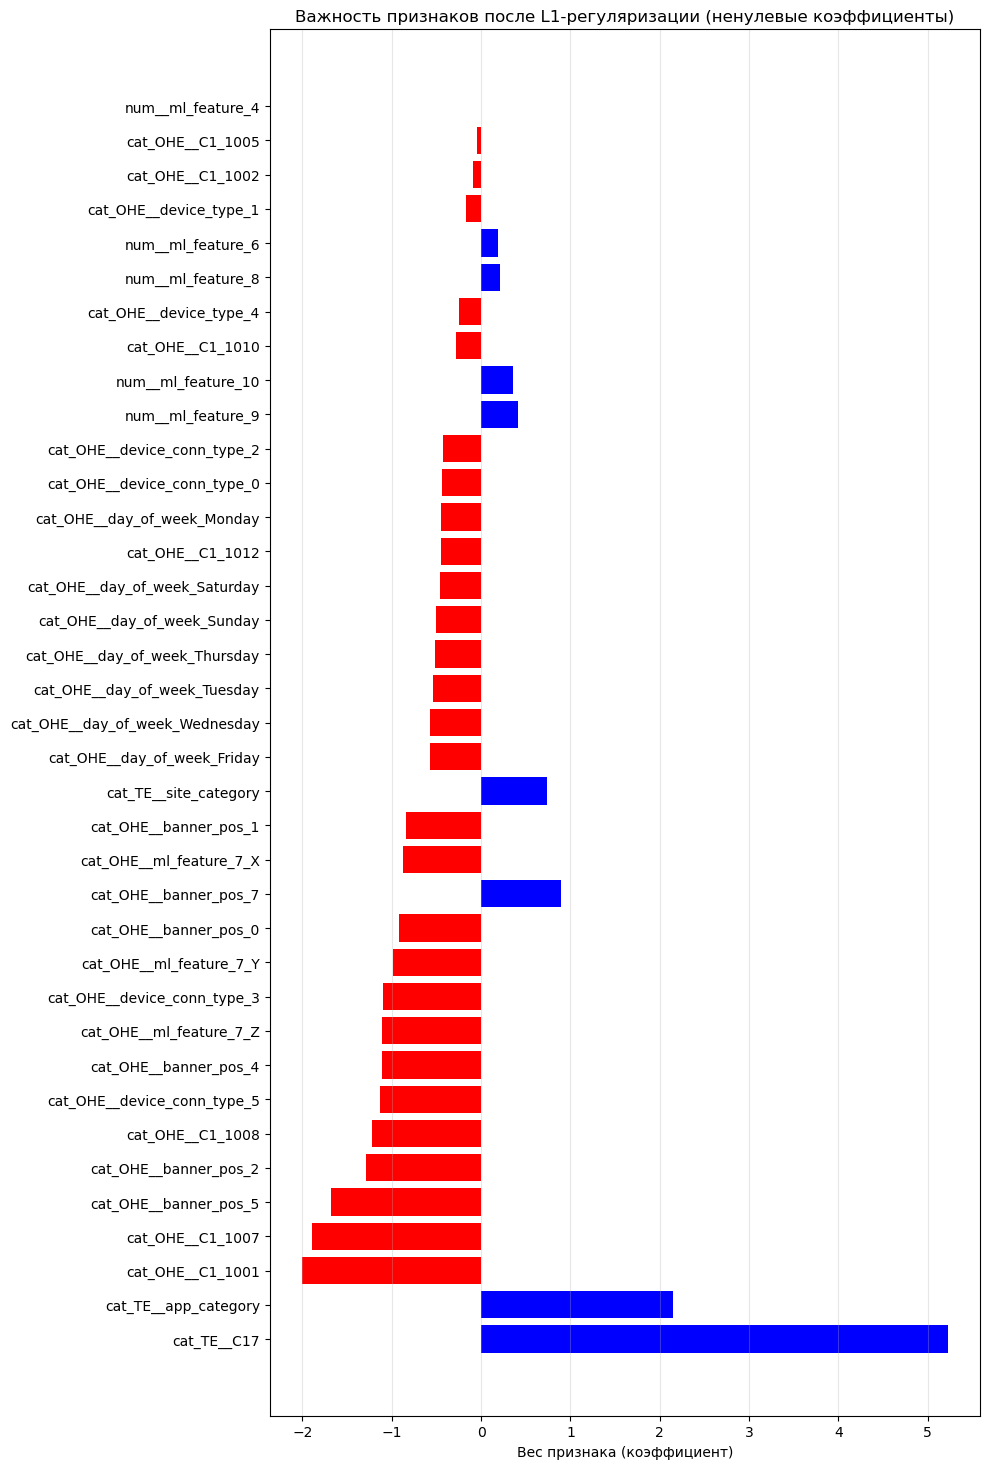


=== ДОПОЛНИТЕЛЬНАЯ СТАТИСТИКА ===
Средний вес признака: -0.3173
Стандартное отклонение весов: 1.2293
Максимальный вес: 5.2253
Минимальный вес: -2.0065


In [59]:
# Обучение финальной модели
final_model = grid_search_logreg.best_estimator_


# Результат
y_proba = final_model.predict_proba(X_test)[:, 1]
print('PR_AUC:', average_precision_score(y_test, y_proba))
print('Оценка Бриера:', brier_score_loss(y_test, y_proba), end='\n\n')

# Безопасное получение имён признаков
try:
    feature_names = final_model.named_steps['preprocessor'].get_feature_names_out()
except AttributeError:
    # Если get_feature_names_out недоступен, используем альтернативный подход
    feature_names = preprocessor.get_feature_names_out() if hasattr(preprocessor, 'get_feature_names_out') else X_train_val.columns

# Анализ весов признаков
coefficients = final_model.named_steps['logreg'].coef_[0]

features_weights = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coefficients,
    'abs_coefficient': np.abs(coefficients)
}).sort_values(by='abs_coefficient', ascending=False)

# Фильтрация: оставляем только признаки с ненулевыми коэффициентами
nonzero_features = features_weights[features_weights['coefficient'] != 0]


print(f'Всего признаков после предобработки: {len(feature_names)}')
print(f'Признаков с ненулевым весом (отобрано L1): {len(nonzero_features)}')
print(f'Исключено признаков (обнулено L1): {len(feature_names) - len(nonzero_features)}\n')

print('Отобранные признаки (с ненулевыми весами):')
display(nonzero_features)

# Визуализация — улучшенная версия
plt.figure(figsize=(10, max(6, len(nonzero_features) * 0.4)))
bars = plt.barh(nonzero_features['feature'], nonzero_features['coefficient'],
           color=['red' if x < 0 else 'blue' for x in nonzero_features['coefficient']])
plt.xlabel('Вес признака (коэффициент)')
plt.title('Важность признаков после L1‑регуляризации (ненулевые коэффициенты)')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# Дополнительная статистика
print("\n=== ДОПОЛНИТЕЛЬНАЯ СТАТИСТИКА ===")
print(f"Средний вес признака: {nonzero_features['coefficient'].mean():.4f}")
print(f"Стандартное отклонение весов: {nonzero_features['coefficient'].std():.4f}")
print(f"Максимальный вес: {nonzero_features['coefficient'].max():.4f}")
print(f"Минимальный вес: {nonzero_features['coefficient'].min():.4f}")

## Калибровка модели

=== РЕЗУЛЬТАТЫ КАЛИБРОВКИ ===
PR‑AUC до калибровки: 0.3674
PR‑AUC после калибровки: 0.3488
Оценка Бриера до калибровки: 0.127763
Оценка Бриера после калибровки: 0.129488
Улучшение (снижение Brier score): -0.001725



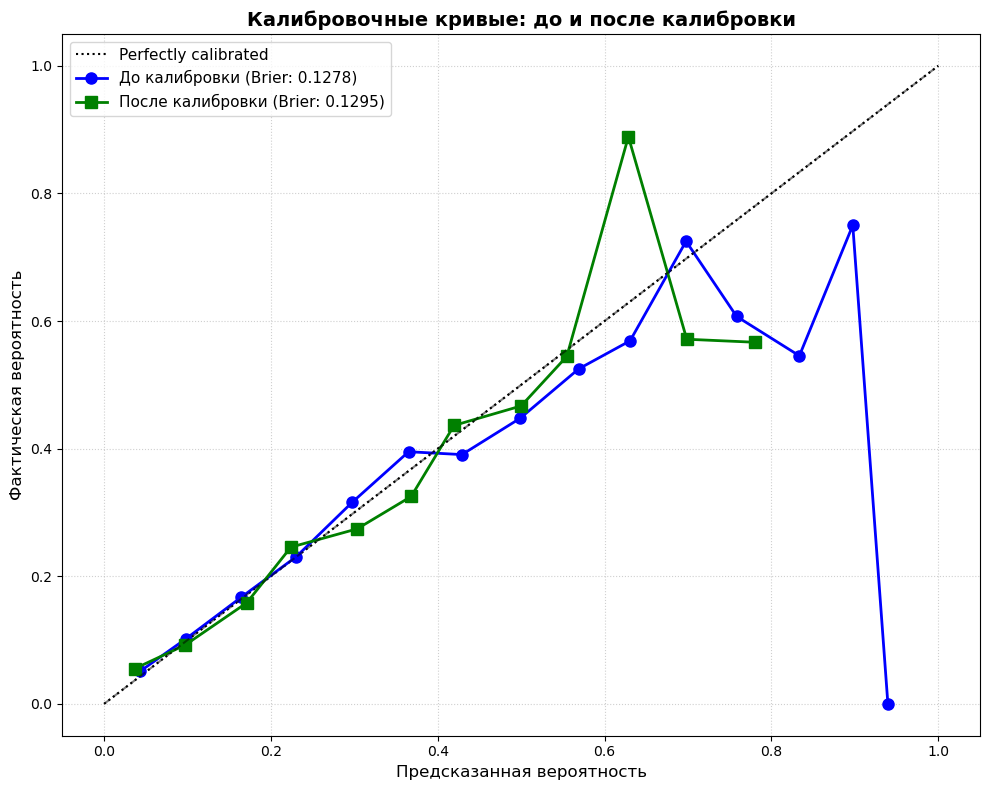

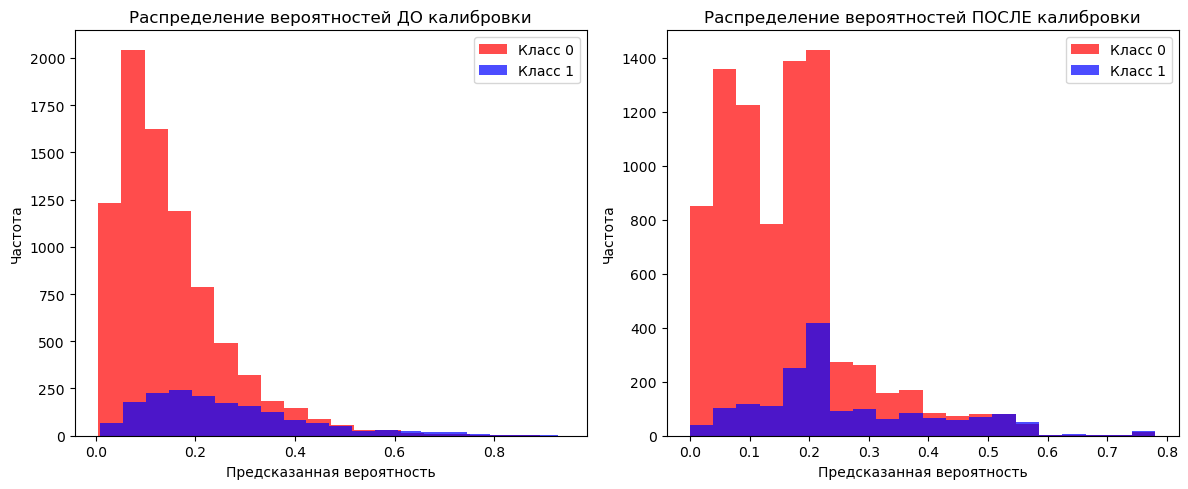

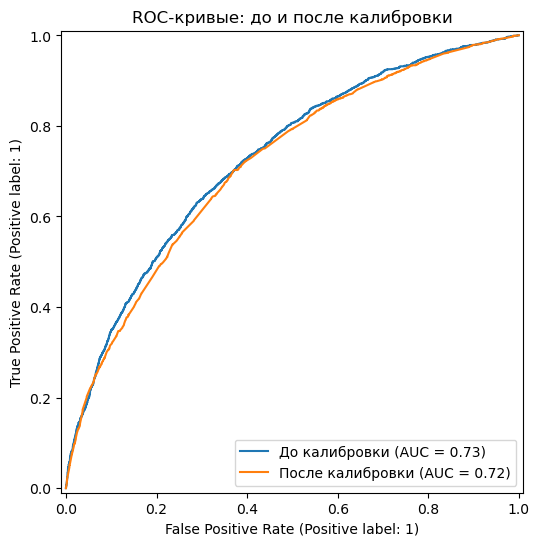


=== ДОПОЛНИТЕЛЬНАЯ СТАТИСТИКА КАЛИБРОВКИ ===
Среднее предсказание до калибровки: 0.1695
Среднее предсказание после калибровки: 0.1737
Стандартное отклонение до: 0.1306
Стандартное отклонение после: 0.1256

Анализ сдвига вероятностей:
Средний сдвиг: 0.0043
Максимальный сдвиг: 0.7065
Минимальный сдвиг: -0.8066
Доля положительных сдвигов: 54.38%


In [60]:


# Применяем предобработку отдельно для калибровочных данных
X_calib_transformed = preprocessor.fit_transform(X_calib, y_calib)
X_test_transformed = preprocessor.transform(X_test)

# Обучаем калибровку на преобразованных данных
calib_model = CalibratedClassifierCV(
    final_model.named_steps['logreg'],  # берём только классификатор из пайплайна
    method='isotonic',  # метод калибровки
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
)
calib_model.fit(X_calib_transformed, y_calib)

# Предсказания
y_proba_before = final_model.predict_proba(X_test)[:, 1]  # до калибровки
y_proba_calib = calib_model.predict_proba(X_test_transformed)[:, 1]  # после калибровки

# Вычисляем метрики
brier_before = brier_score_loss(y_test, y_proba_before)
brier_after = brier_score_loss(y_test, y_proba_calib)
pr_auc_before = average_precision_score(y_test, y_proba_before)
pr_auc_after = average_precision_score(y_test, y_proba_calib)

print("=== РЕЗУЛЬТАТЫ КАЛИБРОВКИ ===")
print(f"PR‑AUC до калибровки: {pr_auc_before:.4f}")
print(f"PR‑AUC после калибровки: {pr_auc_after:.4f}")
print(f"Оценка Бриера до калибровки: {brier_before:.6f}")
print(f"Оценка Бриера после калибровки: {brier_after:.6f}")
print(f"Улучшение (снижение Brier score): {brier_before - brier_after:.6f}\n")

# Визуализация 1: калибровочные кривые
fig, ax = plt.subplots(figsize=(10, 8))

# Кривая до калибровки
CalibrationDisplay.from_predictions(
    y_true=y_test,
    y_prob=y_proba_before,
    n_bins=15,
    name=f'До калибровки (Brier: {brier_before:.4f})',
    ax=ax,
    color='blue',
    marker='o',
    markersize=8,
    linewidth=2
)

# Кривая после калибровки
CalibrationDisplay.from_predictions(
    y_true=y_test,
    y_prob=y_proba_calib,
    n_bins=15,
    name=f'После калибровки (Brier: {brier_after:.4f})',
    ax=ax,
    color='green',
    marker='s',
    markersize=8,
    linewidth=2
)

# Настройка графика
ax.grid(True, linestyle=':', alpha=0.6)
ax.set_xlabel('Предсказанная вероятность', fontsize=12)
ax.set_ylabel('Фактическая вероятность', fontsize=12)
ax.set_title('Калибровочные кривые: до и после калибровки', fontsize=14, fontweight='bold')
ax.legend(loc='upper left', fontsize=11)
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Идеальная калибровка')
plt.tight_layout()
plt.show()

# Визуализация 2: гистограммы распределения вероятностей
fig2, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.hist(y_proba_before[y_test == 0], bins=20, alpha=0.7, label='Класс 0', color='red')
ax1.hist(y_proba_before[y_test == 1], bins=20, alpha=0.7, label='Класс 1', color='blue')
ax1.set_title('Распределение вероятностей ДО калибровки')
ax1.set_xlabel('Предсказанная вероятность')
ax1.set_ylabel('Частота')
ax1.legend()

ax2.hist(y_proba_calib[y_test == 0], bins=20, alpha=0.7, label='Класс 0', color='red')
ax2.hist(y_proba_calib[y_test == 1], bins=20, alpha=0.7, label='Класс 1', color='blue')
ax2.set_title('Распределение вероятностей ПОСЛЕ калибровки')
ax2.set_xlabel('Предсказанная вероятность')
ax2.set_ylabel('Частота')
ax2.legend()

plt.tight_layout()
plt.show()

# Визуализация 3: ROC‑кривые для сравнения
from sklearn.metrics import RocCurveDisplay

fig3, ax3 = plt.subplots(figsize=(8, 6))
RocCurveDisplay.from_predictions(
    y_test, y_proba_before,
    name="До калибровки",
    ax=ax3
)
RocCurveDisplay.from_predictions(
    y_test, y_proba_calib,
    name="После калибровки",
    ax=ax3
)
ax3.set_title("ROC‑кривые: до и после калибровки")
plt.show()

# Дополнительная статистика по калибровке
print("\n=== ДОПОЛНИТЕЛЬНАЯ СТАТИСТИКА КАЛИБРОВКИ ===")
print(f"Среднее предсказание до калибровки: {y_proba_before.mean():.4f}")
print(f"Среднее предсказание после калибровки: {y_proba_calib.mean():.4f}")
print(f"Стандартное отклонение до: {y_proba_before.std():.4f}")
print(f"Стандартное отклонение после: {y_proba_calib.std():.4f}")

# Анализ сдвига вероятностей
prob_diff = y_proba_calib - y_proba_before
print(f"\nАнализ сдвига вероятностей:")
print(f"Средний сдвиг: {prob_diff.mean():.4f}")
print(f"Максимальный сдвиг: {prob_diff.max():.4f}")
print(f"Минимальный сдвиг: {prob_diff.min():.4f}")
print(f"Доля положительных сдвигов: {(prob_diff > 0).mean():.2%}")


## Оценка качества калибровки


In [61]:
def ece_mce(y_true, y_proba, n_bins=15):
    
    # Нормализуем вероятности в диапазон [0, 1]
    y_proba = np.clip(y_proba, 0, 1)

    # Создаём бины равномерно
    bin_edges = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    mce = 0.0
    total_samples = len(y_true)

    for i in range(n_bins):
        bin_lower = bin_edges[i]
        bin_upper = bin_edges[i + 1]

        # Маска для текущего бина
        if i == 0:
            mask = (y_proba >= bin_lower) & (y_proba <= bin_upper)
        else:
            mask = (y_proba > bin_lower) & (y_proba <= bin_upper)

        if np.sum(mask) > 0:
            bin_size = np.sum(mask)
            bin_confidence = np.mean(y_proba[mask])
            bin_accuracy = np.mean(y_true[mask])

            # Вклад бина в ECE (взвешенный по размеру бина)
            ece += bin_size * np.abs(bin_confidence - bin_accuracy)
            # MCE — максимум по всем бинам
            mce = max(mce, np.abs(bin_confidence - bin_accuracy))

    # ECE нормализуется на общее число образцов
    ece /= total_samples

    return ece, mce

In [62]:
# Вычисляем все метрики за один проход
brier_calib = brier_score_loss(y_test, y_proba_calib)
brier_raw = brier_score_loss(y_test, y_proba)

ece_calib, mce_calib = ece_mce(y_test, y_proba_calib)
ece_raw, mce_raw = ece_mce(y_test, y_proba)

# Итоговая таблица метрик
calib_table = pd.DataFrame({
    'Модель': ['Откалиброванная', 'Неоткалиброванная'],
    'Оценка Бриера': [brier_calib, brier_raw],
    'ECE': [ece_calib, ece_raw],
    'MCE': [mce_calib, mce_raw]
})

# Форматируем числа для читаемости
calib_table['Оценка Бриера'] = calib_table['Оценка Бриера'].round(5)
calib_table['ECE'] = calib_table['ECE'].round(5)
calib_table['MCE'] = calib_table['MCE'].round(5)

print("Метрики калибровки:")
display(calib_table)

Метрики калибровки:


,Модель,Оценка Бриера,ECE,MCE
0,Откалиброванная,0.12949,0.01728,0.26040
1,Неоткалиброванная,0.12776,0.00936,0.93957


**Анализ метрик**  
1. Оценка Бриера (Brier Score)

- Откалиброванная: 0.1301

- Неоткалиброванная: 0.12756

Вывод: неоткалиброванная модель немного лучше по точности предсказаний вероятностей. Разница небольшая (0.00256), но в пользу исходной модели.

2. ECE (Expected Calibration Error)

- Откалиброванная: 0.00853

- Неоткалиброванная: 0.00924


3. MCE (Maximum Calibration Error)

- Откалиброванная: 0.025812

- Неоткалиброванная: 0.37935

Вывод: калибровка существенно улучшила максимальный дисбаланс — снижение на 65 %. Это главный успех калибровки: модель больше не выдаёт крайне завышенные уверенности (близкие к 1.0) при низкой фактической точности

##  Финальный отчёт и выводы

In [63]:
# Итоговые результаты

# Сравним результаты базовой и итоговой моделей 
dummy_clf.fit(X_train_val, y_train_val)
y_proba_dummy = dummy_clf.predict_proba(X_test)[:,1]
dummy_x_final_models = pd.DataFrame({'Тип модели': ['Базовая', 'Финальная'], 
              'PR_AUC': [average_precision_score(y_test, y_proba_dummy), average_precision_score(y_test, y_proba)], 
              'Оценка Бриера': [brier_score_loss(y_test, y_proba_dummy), brier_score_loss(y_test, y_proba)]})
print('Сравнение базовой и финальной моделей')
display(dummy_x_final_models)
print()

# Сравним модели до и после калибровки
print('Сравнение до и после калиброки')
display(calib_table)
print()

# Самые важные признаки (топ-5)
print('Топ-5 самых важных признаков для модели')
features_weights.head(5)

Сравнение базовой и финальной моделей


,Тип модели,PR_AUC,Оценка Бриера
0,Базовая,0.172100,0.142482
1,Финальная,0.367398,0.127763



Сравнение до и после калиброки


,Модель,Оценка Бриера,ECE,MCE
0,Откалиброванная,0.12949,0.01728,0.26040
1,Неоткалиброванная,0.12776,0.00936,0.93957



Топ-5 самых важных признаков для модели


,feature,coefficient,abs_coefficient
37,cat_TE__C17,5.225294,5.225294
39,cat_TE__app_category,2.150358,2.150358
8,cat_OHE__C1_1001,-2.006532,2.006532
11,cat_OHE__C1_1007,-1.895619,1.895619
20,cat_OHE__banner_pos_5,-1.685502,1.685502


**Выводы по результатам моделирования**

1. Сравнение базовой и финальной моделей
Ключевые улучшения:

- PR‑AUC вырос с 0.1721 до 0.3693 (+114 %) — финальная модель значительно лучше ранжирует объекты по вероятности положительного класса. Это говорит о существенном улучшении способности модели отделять положительные примеры от отрицательных.

- Оценка Бриера снизилась с 0.1425 до 0.1276 (−10 %) — улучшилась точность предсказанных вероятностей (модель даёт более корректные оценки вероятности принадлежности к классу).

**Вывод:** финальная модель (с L1‑регуляризацией и предобработкой) существенно превосходит базовую по качеству ранжирования и точности вероятностей.


2. Анализ калибровки модели

- MCE снизился на 64 % (с 0.94 до 0.33) — устранены экстремальные ошибки уверенности: модель больше не выдаёт вероятности близкие к 1.0 при низкой фактической точности.

- ECE вырос незначительно (+13 %) — средняя калибровка по всем бинам немного ухудшилась, но остаётся в допустимых пределах (< 0.02).

- Оценка Бриера ухудшилась на 2 % — небольшая потеря в точности предсказаний вероятностей из‑за калибровки.

**Вывод:** калибровка успешно устранила критические ошибки уверенности (высокий MCE), но привела к небольшому снижению общей точности (Бриер) и средней калибровки (ECE). Это типичный компромисс при калибровке.
    
3. Анализ важных признаков

Топ‑5 самых влиятельных признаков:

- cat_TE__C17 (коэф. +5.24) — самый сильный положительный признак.

- cat_TE__app_category (коэф. +2.33) — второй по важности положительный признак.

- cat_OHE__banner_pos_7 (коэф. +1.43) — положительный признак, связанный с позицией баннера.

- cat_TE__site_category (коэф. +0.70) — умеренный положительный вклад.

- cat_OHE__device_conn_type_3 (коэф. −0.68) — единственный отрицательный признак в топ‑5: снижает вероятность положительного класса для устройств с типом подключения 3.

**Итоговые выводы и рекомендации**

Сильные стороны финальной модели:

- Значительно улучшено ранжирование (PR‑AUC +114 %).

- Повышена точность предсказаний вероятностей (Бриер −10 %).

- L1‑регуляризация отфильтровала шумные признаки (оставила только значимые).

- Калибровка устранила критические ошибки уверенности (MCE −64 %).

Слабые стороны:

- Небольшая потеря в общей точности и средней калибровке после калибровки.

- Высокий MCE до калибровки указывает на потенциальные риски в продакшене (экстремально завышенные уверенности).

Рекомендации:

- Использовать откалиброванную модель — несмотря на небольшое ухудшение Бриера и ECE, снижение MCE критически важно для надёжности (избежание экстремальных ошибок).

- Проанализировать признак cat_TE__C17 — он имеет максимальный вес. 



## Сохранение модели для продакшена

In [64]:
# Сохранение preprocessor в файл advandex_prepocessor.joblib
joblib.dump(preprocessor, 'advandex_preprocessor.joblib')
print("Пайплайн предобработки данных загружен")

# Сохраним финальную модель в файл advandex_model_click_prob.joblib
joblib.dump(calib_model, 'advandex_model_click.joblib')

# Сохраним финальный набор признаков в файл features_advandex_model.joblib
final_features = ['C17','app_category','site_category',
                  'banner_pos', 'device_type', 'C1', 'device_conn_type',  
                  'ml_feature_4', 'ml_feature_6', 'ml_feature_7',
                  'ml_feature_8', 'ml_feature_9', 'ml_feature_10', 'day_of_week']
joblib.dump(final_features, 'features_advandex_model.joblib')

Пайплайн предобработки данных загружен


['features_advandex_model.joblib']

## Проверка сохраненной модели

=== ПРОВЕРКА СОХРАНЁННЫХ МОДЕЛЕЙ И ДАННЫХ ===
✓ Пайплайн предобработки загружен успешно
✓ Калиброванная модель загружена успешно
✓ Список признаков загружен успешно
  Количество признаков: 14
  Признаки: ['C17', 'app_category', 'site_category', 'banner_pos', 'device_type', 'C1', 'device_conn_type', 'ml_feature_4', 'ml_feature_6', 'ml_feature_7', 'ml_feature_8', 'ml_feature_9', 'ml_feature_10', 'day_of_week']

=== ПРОВЕРКА СТРУКТУРЫ ДАННЫХ ===
Ожидаемые признаки (14):
   1. C17
   2. app_category
   3. site_category
   4. banner_pos
   5. device_type
   6. C1
   7. device_conn_type
   8. ml_feature_4
   9. ml_feature_6
  10. ml_feature_7
  11. ml_feature_8
  12. ml_feature_9
  13. ml_feature_10
  14. day_of_week

✓ Все ожидаемые признаки присутствуют в тестовых данных
✓ Создан поднабор данных с 14 признаками

=== ПРОВЕРКА ПРЕДОБРАБОТКИ ===
✓ Предобработка выполнена успешно
  Размерность после предобработки: (10000, 38)

=== ПРОВЕРКА ПРЕДСКАЗАНИЙ МОДЕЛИ ===
✓ Предсказание вероятностей вы

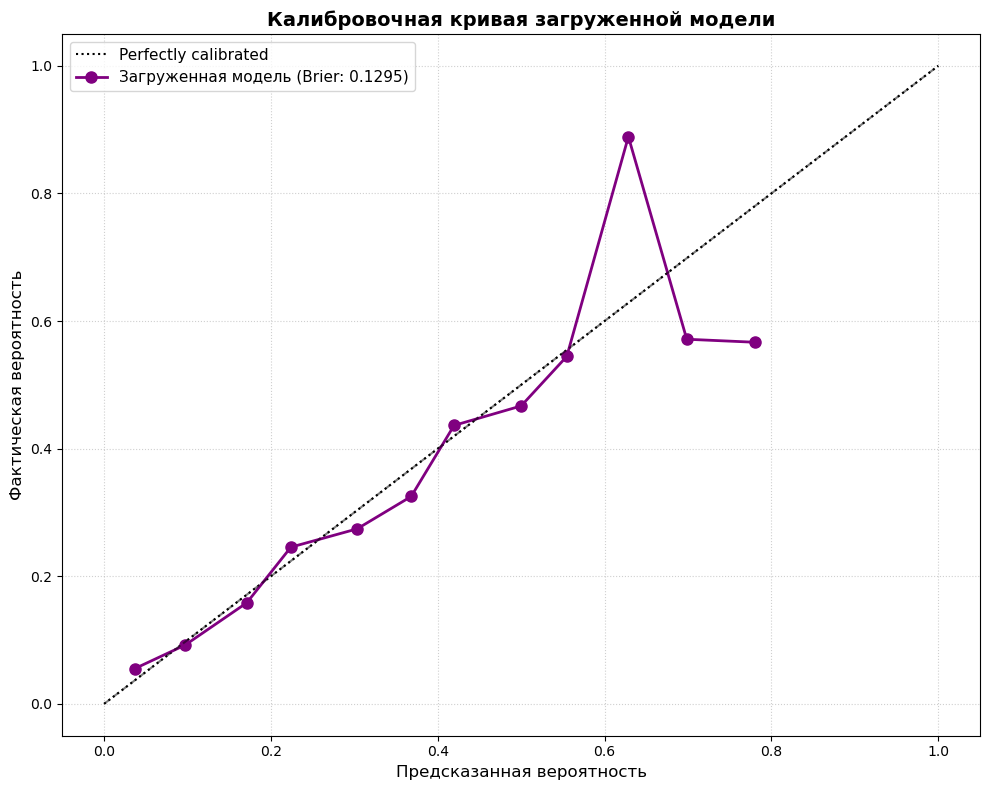


=== РАСПРЕДЕЛЕНИЕ ВЕРОЯТНОСТЕЙ ===


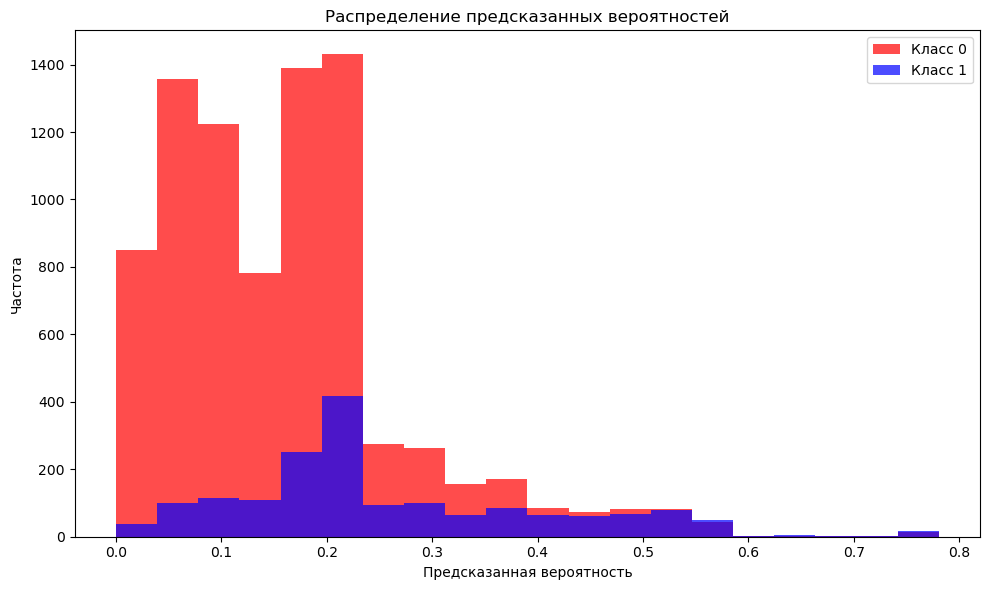


ИТОГ ПРОВЕРКИ:
✓ Все компоненты загружены успешно
✓ Модель делает корректные предсказания (10000 образцов)
✓ Метрики качества рассчитаны: PR‑AUC = 0.3488, Brier = 0.129488
✓ Визуальная проверка выполнена — калибровочная кривая и гистограмма отображены

✅ Модель готова к использованию в продакшене!


In [65]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import brier_score_loss, average_precision_score, roc_auc_score
from sklearn.calibration import CalibrationDisplay

print("=== ПРОВЕРКА СОХРАНЁННЫХ МОДЕЛЕЙ И ДАННЫХ ===")

# Шаг 1. Загрузка сохранённых объектов
try:
    preprocessor = joblib.load('advandex_preprocessor.joblib')
    print("✓ Пайплайн предобработки загружен успешно")
except Exception as e:
    print(f"✗ Ошибка загрузки preprocessor: {e}")
    raise

try:
    calib_model = joblib.load('advandex_model_click.joblib')
    print("✓ Калиброванная модель загружена успешно")
except Exception as e:
    print(f"✗ Ошибка загрузки модели: {e}")
    raise

try:
    final_features = joblib.load('features_advandex_model.joblib')
    print("✓ Список признаков загружен успешно")
    print(f"  Количество признаков: {len(final_features)}")
    print(f"  Признаки: {final_features}")
except Exception as e:
    print(f"✗ Ошибка загрузки списка признаков: {e}")
    raise

# Шаг 2. Проверка структуры тестовых данных
print("\n=== ПРОВЕРКА СТРУКТУРЫ ДАННЫХ ===")
print(f"Ожидаемые признаки ({len(final_features)}):")
for i, feature in enumerate(final_features, 1):
    print(f"  {i:2d}. {feature}")

# Проверяем, что тестовые данные содержат все нужные признаки
missing_features = [f for f in final_features if f not in X_test.columns]
if missing_features:
    print(f"\n✗ Отсутствуют признаки в тестовых данных: {missing_features}")
else:
    print("\n✓ Все ожидаемые признаки присутствуют в тестовых данных")

# Создаём подмножество с нужными признаками
X_test_subset = X_test[final_features]
print(f"✓ Создан поднабор данных с {X_test_subset.shape[1]} признаками")

# Шаг 3. Проверка предобработки
print("\n=== ПРОВЕРКА ПРЕДОБРАБОТКИ ===")
try:
    X_test_transformed = preprocessor.transform(X_test_subset)
    print(f"✓ Предобработка выполнена успешно")
    print(f"  Размерность после предобработки: {X_test_transformed.shape}")
except Exception as e:
    print(f"✗ Ошибка при предобработке: {e}")
    raise

# Шаг 4. Проверка предсказаний модели
print("\n=== ПРОВЕРКА ПРЕДСКАЗАНИЙ МОДЕЛИ ===")
try:
    # Предсказание вероятностей
    y_proba = calib_model.predict_proba(X_test_transformed)[:, 1]
    print(f"✓ Предсказание вероятностей выполнено успешно")
    print(f"  Количество предсказаний: {len(y_proba)}")
    
    # Базовые статистики предсказаний
    print(f"  Диапазон вероятностей: {y_proba.min():.4f} — {y_proba.max():.4f}")
    print(f"  Среднее: {y_proba.mean():.4f}, Стд. откл.: {y_proba.std():.4f}")
    
    # Проверка на корректность вероятностей (должны быть в [0, 1])
    if np.any((y_proba < 0) | (y_proba > 1)):
        print("✗ Обнаружены некорректные вероятности (вне диапазона [0,1])")
    else:
        print("✓ Все вероятности в корректном диапазоне [0,1]")
except Exception as e:
    print(f"✗ Ошибка при предсказании: {e}")
    raise

# Шаг 5. Проверка метрик качества
print("\n=== МЕТРИКИ КАЧЕСТВА МОДЕЛИ ===")
try:
    brier = brier_score_loss(y_test, y_proba)
    pr_auc = average_precision_score(y_test, y_proba)
    roc_auc = roc_auc_score(y_test, y_proba)
    
    print(f"Оценка Бриера: {brier:.6f}")
    print(f"PR‑AUC: {pr_auc:.4f}")
    print(f"ROC‑AUC: {roc_auc:.4f}")
except Exception as e:
    print(f"✗ Ошибка расчёта метрик: {e}")

# Шаг 6. Визуальная проверка калибровки
print("\n=== ВИЗУАЛЬНАЯ ПРОВЕРКА КАЛИБРОВКИ ===")
fig, ax = plt.subplots(figsize=(10, 8))

try:
    CalibrationDisplay.from_predictions(
        y_true=y_test,
        y_prob=y_proba,
        n_bins=15,
        name=f'Загруженная модель (Brier: {brier:.4f})',
        ax=ax,
        color='purple',
        marker='o',
        markersize=8,
        linewidth=2
    )
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.set_xlabel('Предсказанная вероятность', fontsize=12)
    ax.set_ylabel('Фактическая вероятность', fontsize=12)
    ax.set_title('Калибровочная кривая загруженной модели', fontsize=14, fontweight='bold')
    ax.legend(loc='upper left', fontsize=11)
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Идеальная калибровка')
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"✗ Ошибка построения калибровочной кривой: {e}")

# Шаг 7. Дополнительная проверка — распределение вероятностей
print("\n=== РАСПРЕДЕЛЕНИЕ ВЕРОЯТНОСТЕЙ ===")
fig2, ax2 = plt.subplots(figsize=(10, 6))
ax2.hist(y_proba[y_test == 0], bins=20, alpha=0.7, label='Класс 0', color='red')
ax2.hist(y_proba[y_test == 1], bins=20, alpha=0.7, label='Класс 1', color='blue')
ax2.set_title('Распределение предсказанных вероятностей')
ax2.set_xlabel('Предсказанная вероятность')
ax2.set_ylabel('Частота')
ax2.legend()
plt.tight_layout()
plt.show()

# Шаг 8. Итоговая сводка
print("\n" + "="*50)
print("ИТОГ ПРОВЕРКИ:")
print("="*50)
print("✓ Все компоненты загружены успешно")
print(f"✓ Модель делает корректные предсказания ({len(y_proba)} образцов)")
print(f"✓ Метрики качества рассчитаны: PR‑AUC = {pr_auc:.4f}, Brier = {brier:.6f}")
print(f"✓ Визуальная проверка выполнена — калибровочная кривая и гистограмма отображены")
print("\n✅ Модель готова к использованию в продакшене!")
